# 🥊 UFC Dataset - Exploratory Data Analysis (1994–2026)

**Objective:** Understand the structure, distributions, trends, and relationships in the UFC fights and fighters dataset before building predictive models.

**Notebook Structure:**
1. Environment Setup
2. Data Loading & Schema Inspection
3. Data Cleaning & Type Parsing
4. Fight-Level EDA
   - 4.1 Temporal Growth of the UFC
   - 4.2 Win Methods
   - 4.3 Weight Class Landscape
   - 4.4 Fight Duration & Round Distribution
   - 4.5 Striking & Grappling Performance
5. Fighter-Level EDA
   - 5.1 Physical Attributes
   - 5.2 Stance Distribution
   - 5.3 Career Records
   - 5.4 Performance Ratings
6. Era-Based Trend Analysis
7. Correlation Heatmaps
8. Key Insights Summary

---
## 1. Environment Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
import re

# ── Aesthetics ──────────────────────────────────────────────────────────────
PALETTE   = ['#E8003D', '#0D1117', '#C0C0C0', '#FFD700', '#1A6B3C', '#3A86FF', '#FF6B35', '#9B5DE5']
BG_COLOR  = '#0D1117'
TEXT_COLOR = '#E8E8E8'
GRID_COLOR = '#2A2A3A'

plt.rcParams.update({
    'figure.facecolor':  BG_COLOR,
    'axes.facecolor':    BG_COLOR,
    'axes.edgecolor':    GRID_COLOR,
    'axes.labelcolor':   TEXT_COLOR,
    'axes.titlecolor':   TEXT_COLOR,
    'xtick.color':       TEXT_COLOR,
    'ytick.color':       TEXT_COLOR,
    'text.color':        TEXT_COLOR,
    'grid.color':        GRID_COLOR,
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'legend.facecolor':  '#1A1A2E',
    'legend.edgecolor':  GRID_COLOR,
    'legend.labelcolor': TEXT_COLOR,
})

RED   = PALETTE[0]
GOLD  = PALETTE[3]
BLUE  = PALETTE[5]
GREEN = PALETTE[4]

print('Libraries loaded. Palette configured.')

Libraries loaded. Palette configured.


---
## 2. Data Loading & Schema Inspection

In [ ]:
import os

# Support both Kaggle and local environments
if os.path.exists('/kaggle/input'):
    DATA_DIR = '/kaggle/input/datasets/jossilva3110/ufc-dataset-1994-2026/'
else:
    DATA_DIR = 'dataset/'

fights_raw   = pd.read_csv(f'{DATA_DIR}ufc_gold_dataset_final.csv')
fighters_raw = pd.read_csv(f'{DATA_DIR}ufc_fighters_final.csv')

print(f'Fights   dataset : {fights_raw.shape[0]:,} rows × {fights_raw.shape[1]} columns')
print(f'Fighters dataset : {fighters_raw.shape[0]:,} rows × {fighters_raw.shape[1]} columns')

Fights   dataset : 8,551 rows × 37 columns
Fighters dataset : 4,455 rows × 18 columns


In [ ]:
print('=== FIGHTS SCHEMA ===')
fights_raw.info()
fights_raw.head(3)

=== FIGHTS SCHEMA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8551 entries, 0 to 8550
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Fight_URL             8551 non-null   object
 1   Fighter_1             8551 non-null   object
 2   Fighter_2             8551 non-null   object
 3   Winner                8551 non-null   object
 4   Weight_Class          8551 non-null   object
 5   Method                8551 non-null   object
 6   End_Round             8551 non-null   int64 
 7   End_Time              8551 non-null   object
 8   Total_Fight_Time_Sec  8551 non-null   int64 
 9   Time_Format           8551 non-null   object
 10  F1_KD                 8551 non-null   int64 
 11  F2_KD                 8551 non-null   int64 
 12  F1_Sig_Landed         8551 non-null   int64 
 13  F1_Sig_Att            8551 non-null   int64 
 14  F2_Sig_Landed         8551 non-null   int64 
 15  F2_Sig_Att      

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,...,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,1,0:20,20,No Time Limit,...,0,0,0,0,0,1,0,0,0,1994-03-11
1,http://ufcstats.com/fight-details/4b9ae533ccb3...,Patrick Smith,Ray Wizard,Patrick Smith,Open Weight Bout,Submission,1,0:58,58,No Time Limit,...,0,0,1,0,1,1,0,0,0,1994-03-11
2,http://ufcstats.com/fight-details/00835554f95f...,Royce Gracie,Patrick Smith,Royce Gracie,UFC 2 Tournament Title Bout,KO/TKO,1,1:17,77,No Time Limit,...,1,1,0,0,0,1,1,3,0,1994-03-11


In [ ]:
print('=== FIGHTERS SCHEMA ===')
fighters_raw.info()
fighters_raw.head(3)

=== FIGHTERS SCHEMA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4455 entries, 0 to 4454
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Fighter_Name  4455 non-null   object 
 1   Height        4137 non-null   object 
 2   Weight        4369 non-null   object 
 3   Reach         2515 non-null   object 
 4   Stance        3606 non-null   object 
 5   DOB           3949 non-null   object 
 6   Wins          4455 non-null   int64  
 7   Losses        4455 non-null   int64  
 8   Draws         4455 non-null   int64  
 9   SLpM          4455 non-null   float64
 10  Str_Acc       4455 non-null   object 
 11  SApM          4455 non-null   float64
 12  Str_Def       4455 non-null   object 
 13  TD_Avg        4455 non-null   float64
 14  TD_Acc        4455 non-null   object 
 15  TD_Def        4455 non-null   object 
 16  Sub_Avg       4455 non-null   float64
 17  Fighter_URL   4455 non-null   object 
dtypes: f

,Fighter_Name,Height,Weight,Reach,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Fighter_URL
0,Tom Aaron,NaN,155 lbs.,NaN,NaN,1978-07-13,5,3,0,0.00,0%,0.00,0%,0.0,0%,0%,0.0,http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny Abbadi,"5' 11""",155 lbs.,NaN,Orthodox,1983-07-03,4,6,0,3.29,38%,4.41,57%,0.0,0%,77%,0.0,http://ufcstats.com/fighter-details/15df64c02b...
2,Nariman Abbasov,"5' 8""",155 lbs.,"66.0""",Orthodox,1994-02-01,28,4,0,3.00,20%,5.67,46%,0.0,0%,66%,0.0,http://ufcstats.com/fighter-details/59a9d6dac6...


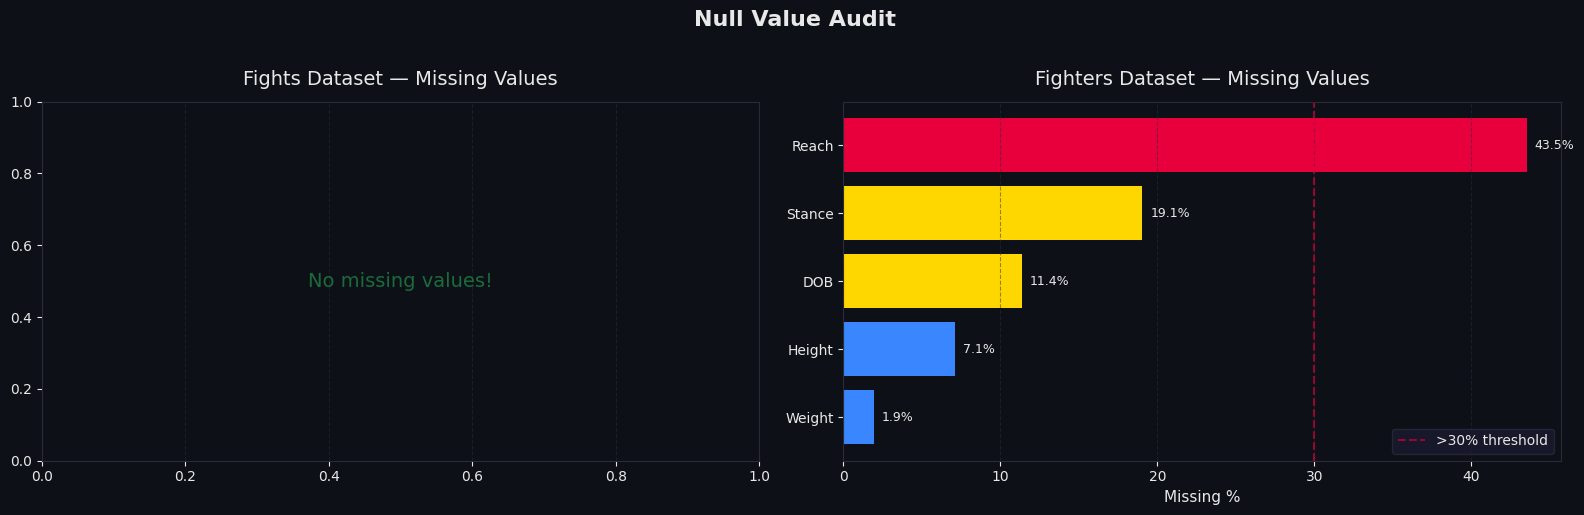

In [ ]:
# Null-value audit
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, title in zip(axes,
                          [fights_raw, fighters_raw],
                          ['Fights Dataset — Missing Values', 'Fighters Dataset — Missing Values']):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        ax.text(0.5, 0.5, 'No missing values!', ha='center', va='center',
                fontsize=14, color=GREEN, transform=ax.transAxes)
    else:
        colors = [RED if v > 30 else GOLD if v > 10 else BLUE for v in null_pct.values]
        bars = ax.barh(null_pct.index, null_pct.values, color=colors, edgecolor='none')
        for bar, val in zip(bars, null_pct.values):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9, color=TEXT_COLOR)
        ax.set_xlabel('Missing %')
        ax.axvline(30, color=RED, linestyle='--', alpha=0.6, label='>30% threshold')
        ax.legend()
    ax.set_title(title, pad=12)
    ax.grid(axis='x')

plt.suptitle('Null Value Audit', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Data Cleaning & Type Parsing

In [ ]:
# ── Fights ──────────────────────────────────────────────────────────────────
fights = fights_raw.copy()
fights['Event_Date'] = pd.to_datetime(fights['Event_Date'])
fights['Year']  = fights['Event_Date'].dt.year
fights['Month'] = fights['Event_Date'].dt.month

# Normalise method into 5 buckets
def bucket_method(m):
    m = str(m).upper()
    if 'KO' in m or 'TKO' in m or 'DOCTOR' in m:
        return 'KO/TKO'
    if 'SUBMISSION' in m:
        return 'Submission'
    if 'UNANIMOUS' in m:
        return 'Decision - Unanimous'
    if 'SPLIT' in m:
        return 'Decision - Split'
    if 'MAJORITY' in m:
        return 'Decision - Majority'
    return 'Other / Overturned'

fights['Method_Bucket'] = fights['Method'].apply(bucket_method)

# Is this a main-event (5-round) fight?
fights['Is_5Rnd'] = fights['Time_Format'].str.startswith('5 Rnd').astype(int)

# Win outcome labels
fights['Is_Finish'] = fights['Method_Bucket'].isin(['KO/TKO', 'Submission']).astype(int)
fights['Is_Decision'] = fights['Method_Bucket'].str.startswith('Decision').astype(int)

# Normalise Weight_Class to standard divisions
WEIGHT_MAP = {
    'Strawweight': 'Strawweight', 'Flyweight': 'Flyweight',
    'Bantamweight': 'Bantamweight', 'Featherweight': 'Featherweight',
    'Lightweight': 'Lightweight', 'Welterweight': 'Welterweight',
    'Middleweight': 'Middleweight', 'Light Heavyweight': 'Light Heavyweight',
    'Heavyweight': 'Heavyweight', 'Open Weight': 'Open Weight',
    "Women's Strawweight": "Women's Strawweight",
    "Women's Flyweight": "Women's Flyweight",
    "Women's Bantamweight": "Women's Bantamweight",
    "Women's Featherweight": "Women's Featherweight",
}
def map_weight(wc):
    wc = str(wc)
    for key, val in WEIGHT_MAP.items():
        if key.lower() in wc.lower():
            return val
    return 'Other'

fights['Division'] = fights['Weight_Class'].apply(map_weight)

print('Fights cleaning done.')
print('Method buckets:', fights['Method_Bucket'].value_counts().to_dict())
print('Division counts:', fights['Division'].value_counts().head(10).to_dict())

Fights cleaning done.
Method buckets: {'Decision - Unanimous': 3083, 'KO/TKO': 2785, 'Submission': 1655, 'Decision - Split': 815, 'Other / Overturned': 115, 'Decision - Majority': 98}
Division counts: {'Lightweight': 1430, 'Welterweight': 1384, 'Middleweight': 1129, 'Bantamweight': 1009, 'Featherweight': 873, 'Heavyweight': 761, 'Light Heavyweight': 749, 'Flyweight': 677, 'Strawweight': 359, 'Other': 94}


In [ ]:
# ── Fighters ─────────────────────────────────────────────────────────────────
fighters = fighters_raw.copy()

# Parse Height: "5' 11"" → cm
def height_to_cm(h):
    if pd.isna(h): return np.nan
    m = re.match(r"(\d+)'\s*(\d+)\"", str(h))
    if m:
        return int(m.group(1)) * 30.48 + int(m.group(2)) * 2.54
    return np.nan

# Parse Weight: "155 lbs." → kg
def weight_to_kg(w):
    if pd.isna(w): return np.nan
    m = re.match(r"([\d.]+)\s*lbs", str(w))
    if m:
        return float(m.group(1)) * 0.453592
    return np.nan

# Parse Reach: "72.0"" → cm
def reach_to_cm(r):
    if pd.isna(r): return np.nan
    m = re.match(r"([\d.]+)\"", str(r))
    if m:
        return float(m.group(1)) * 2.54
    return np.nan

# Parse percentage strings → float
def pct_to_float(p):
    if pd.isna(p): return np.nan
    m = re.match(r"([\d.]+)%", str(p))
    return float(m.group(1)) / 100 if m else np.nan

fighters['Height_cm'] = fighters['Height'].apply(height_to_cm)
fighters['Weight_kg'] = fighters['Weight'].apply(weight_to_kg)
fighters['Reach_cm']  = fighters['Reach'].apply(reach_to_cm)
fighters['DOB']       = pd.to_datetime(fighters['DOB'], errors='coerce')

for col in ['Str_Acc', 'Str_Def', 'TD_Acc', 'TD_Def']:
    fighters[col] = fighters[col].apply(pct_to_float)

fighters['Total_Fights'] = fighters['Wins'] + fighters['Losses'] + fighters['Draws']
fighters['Win_Rate']     = np.where(
    fighters['Total_Fights'] > 0,
    fighters['Wins'] / fighters['Total_Fights'], np.nan
)
# Age at extraction reference point (latest event date)
REF_DATE = pd.Timestamp('2026-03-07')
fighters['Age'] = ((REF_DATE - fighters['DOB']).dt.days / 365.25).round(1)

print('Fighters cleaning done.')
fighters[['Fighter_Name','Height_cm','Weight_kg','Reach_cm','Age','Win_Rate']].describe()

Fighters cleaning done.


,Height_cm,Weight_kg,Reach_cm,Age,Win_Rate
count,4137.000000,4369.000000,2515.000000,3949.000000,4436.000000
mean,178.164699,77.142409,181.746847,40.103064,0.666270
std,8.979971,17.952086,10.838218,8.351208,0.190460
min,139.700000,47.627160,147.320000,20.200000,0.000000
25%,172.720000,65.770840,175.260000,33.800000,0.600000
50%,177.800000,72.574720,182.880000,39.400000,0.691608
75%,185.420000,83.914520,190.500000,45.400000,0.777778
max,226.060000,349.265840,213.360000,83.100000,1.000000


---
## 4. Fight-Level EDA
### 4.1 Temporal Growth of the UFC

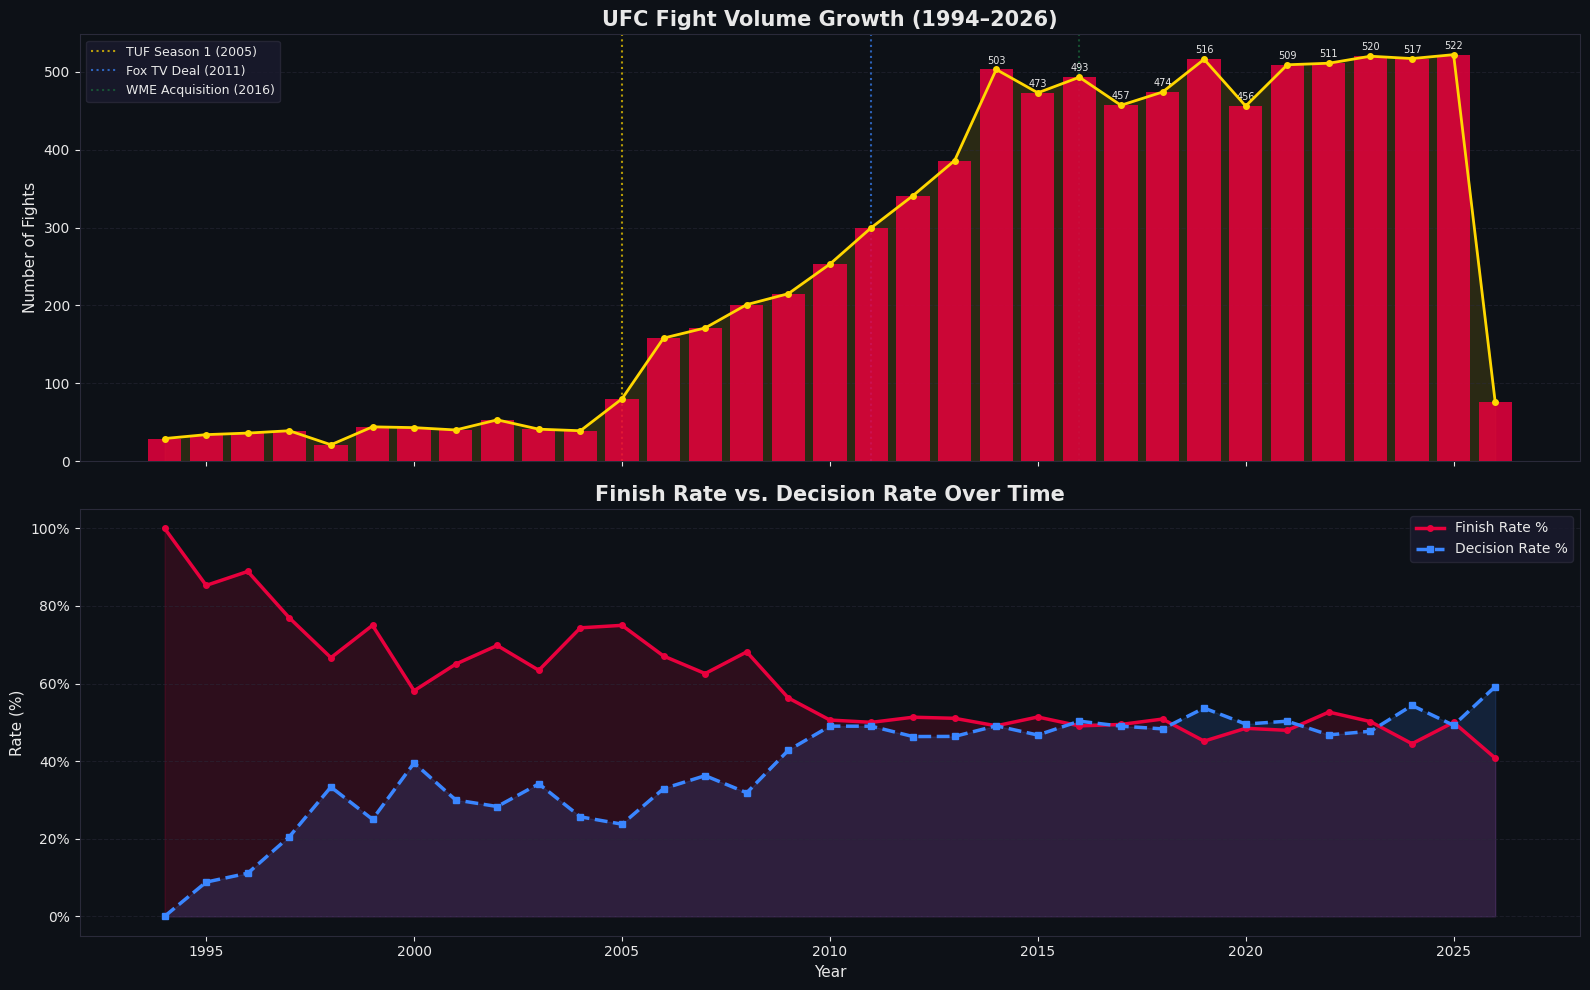


Overall finish rate  : 60.2%
Overall decision rate: 38.5%


In [ ]:
yearly = fights.groupby('Year').agg(
    Fights=('Fight_URL', 'count'),
    Finishes=('Is_Finish', 'sum'),
    Decisions=('Is_Decision', 'sum')
).reset_index()
yearly['Finish_Rate']   = yearly['Finishes']   / yearly['Fights']
yearly['Decision_Rate'] = yearly['Decisions']  / yearly['Fights']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel A – Total fights per year
ax = axes[0]
bars = ax.bar(yearly['Year'], yearly['Fights'], color=RED, alpha=0.85, edgecolor='none', zorder=3)
ax.plot(yearly['Year'], yearly['Fights'], color=GOLD, lw=2, marker='o', ms=4, zorder=4)
ax.fill_between(yearly['Year'], yearly['Fights'], alpha=0.12, color=GOLD)
ax.set_ylabel('Number of Fights')
ax.set_title('UFC Fight Volume Growth (1994–2026)', fontsize=15, fontweight='bold')
ax.axvline(2005, color=GOLD, linestyle=':', alpha=0.7, label='TUF Season 1 (2005)')
ax.axvline(2011, color=BLUE, linestyle=':', alpha=0.7, label='Fox TV Deal (2011)')
ax.axvline(2016, color=GREEN, linestyle=':', alpha=0.7, label='WME Acquisition (2016)')
ax.legend(fontsize=9)
ax.grid(axis='y', zorder=0)
for bar in bars:
    h = bar.get_height()
    if h > 450:
        ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h)}',
                ha='center', va='bottom', fontsize=7, color=TEXT_COLOR)

# Panel B – Finish rate vs decision rate over time
ax2 = axes[1]
ax2.plot(yearly['Year'], yearly['Finish_Rate']*100,   color=RED,  lw=2.5, marker='o', ms=4, label='Finish Rate %')
ax2.plot(yearly['Year'], yearly['Decision_Rate']*100, color=BLUE, lw=2.5, marker='s', ms=4, label='Decision Rate %', linestyle='--')
ax2.fill_between(yearly['Year'], yearly['Finish_Rate']*100,   alpha=0.15, color=RED)
ax2.fill_between(yearly['Year'], yearly['Decision_Rate']*100, alpha=0.15, color=BLUE)
ax2.set_xlabel('Year')
ax2.set_ylabel('Rate (%)')
ax2.set_title('Finish Rate vs. Decision Rate Over Time', fontsize=15, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

print(f"\nOverall finish rate  : {yearly['Finish_Rate'].mean()*100:.1f}%")
print(f"Overall decision rate: {yearly['Decision_Rate'].mean()*100:.1f}%")

### 4.2 Win Methods Distribution

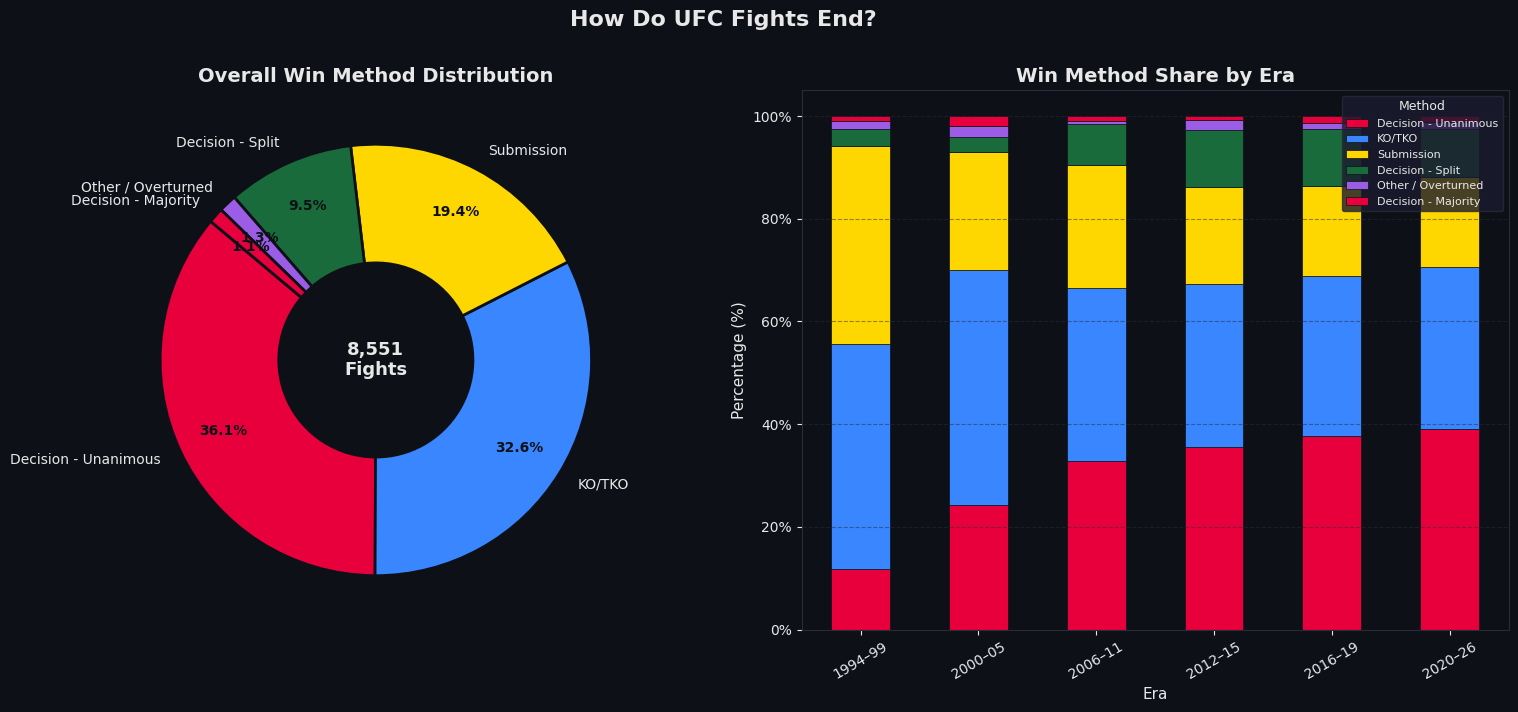

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Donut – Overall method breakdown
ax = axes[0]
method_counts = fights['Method_Bucket'].value_counts()
method_colors = [RED, BLUE, GOLD, GREEN, '#9B5DE5']
wedges, texts, autotexts = ax.pie(
    method_counts.values,
    labels=method_counts.index,
    colors=method_colors[:len(method_counts)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'width': 0.55, 'edgecolor': BG_COLOR, 'linewidth': 2},
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_color(BG_COLOR)
    t.set_fontweight('bold')
ax.text(0, 0, f'{len(fights):,}\nFights', ha='center', va='center',
        fontsize=13, fontweight='bold', color=TEXT_COLOR)
ax.set_title('Overall Win Method Distribution', fontsize=14, fontweight='bold')

# Stacked bar – method share per era
ax2 = axes[1]
era_bins  = [1994, 2000, 2006, 2012, 2016, 2020, 2026]
era_labels = ['1994–99', '2000–05', '2006–11', '2012–15', '2016–19', '2020–26']
fights['Era'] = pd.cut(fights['Year'], bins=era_bins, labels=era_labels, right=False)

era_method = (fights.groupby(['Era', 'Method_Bucket'], observed=True).size()
              .unstack(fill_value=0)
              .div(fights.groupby('Era', observed=True).size(), axis=0) * 100)

era_method[method_counts.index].plot(
    kind='bar', stacked=True, ax=ax2,
    color=method_colors[:len(method_counts)],
    edgecolor=BG_COLOR, linewidth=0.5, rot=30
)
ax2.set_title('Win Method Share by Era', fontsize=14, fontweight='bold')
ax2.set_xlabel('Era')
ax2.set_ylabel('Percentage (%)')
ax2.legend(title='Method', fontsize=8, title_fontsize=9, loc='upper right')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.grid(axis='y')

plt.suptitle('How Do UFC Fights End?', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Weight Class Landscape

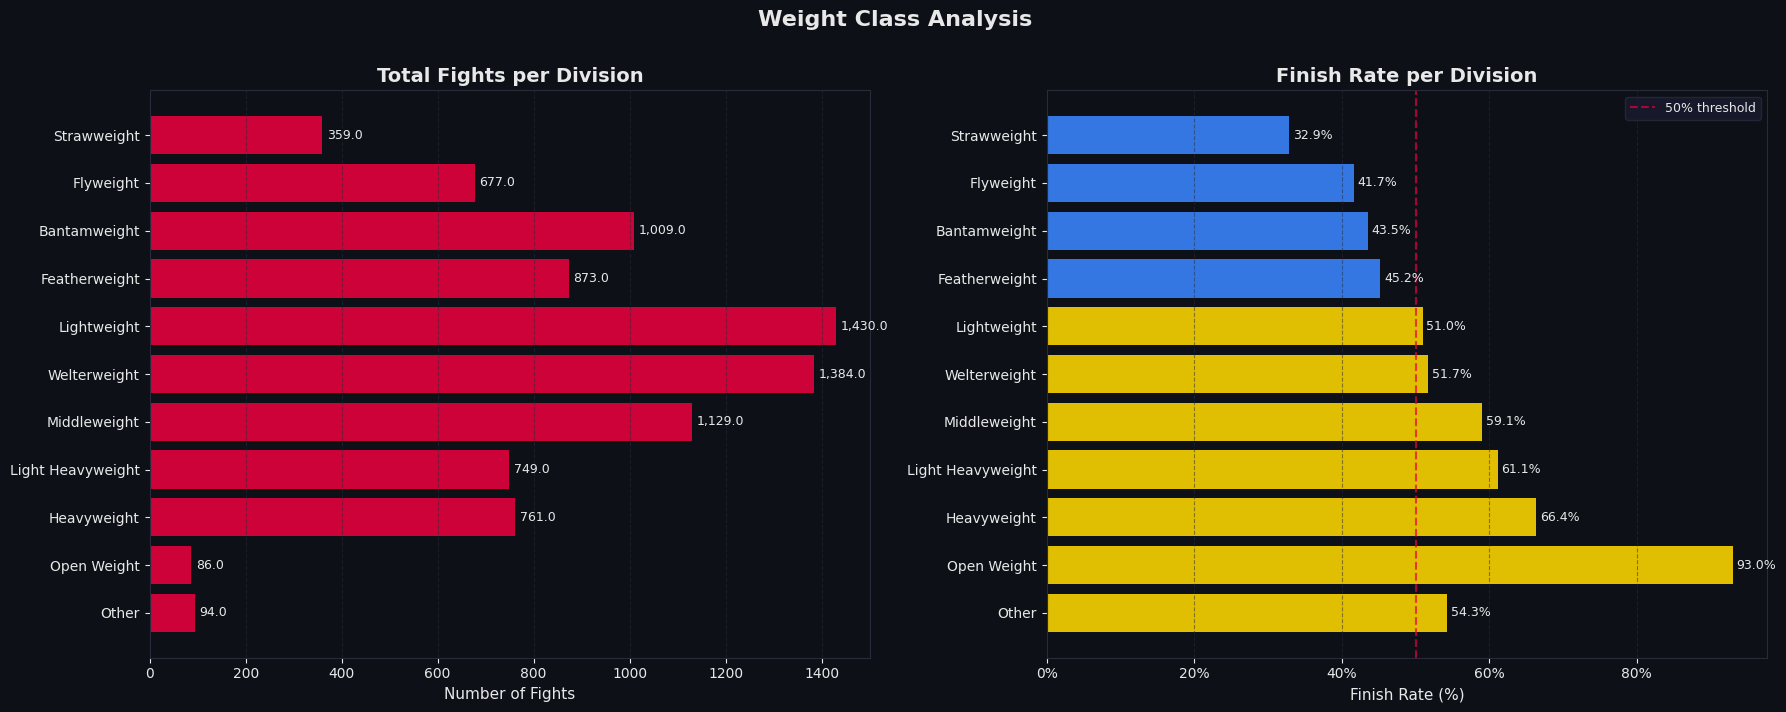

In [ ]:
DIVISION_ORDER = [
    "Strawweight", "Women's Strawweight", "Women's Flyweight",
    "Flyweight", "Women's Bantamweight", "Bantamweight",
    "Women's Featherweight", "Featherweight",
    "Lightweight", "Welterweight", "Middleweight",
    "Light Heavyweight", "Heavyweight", "Open Weight", "Other"
]

div_counts = fights['Division'].value_counts().reindex(DIVISION_ORDER).dropna()
div_finish = (fights.groupby('Division', observed=True)['Is_Finish'].mean() * 100).reindex(div_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left – Fight count by division
ax = axes[0]
bar_colors = [RED if 'Women' not in d else '#FF6B9D' for d in div_counts.index]
bars = ax.barh(div_counts.index, div_counts.values, color=bar_colors, edgecolor='none', alpha=0.88)
for bar, v in zip(bars, div_counts.values):
    ax.text(v + 10, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=9, color=TEXT_COLOR)
ax.set_xlabel('Number of Fights')
ax.set_title('Total Fights per Division', fontsize=14, fontweight='bold')
ax.grid(axis='x')
ax.invert_yaxis()

# Right – Finish rate by division
ax2 = axes[1]
finish_colors = [GOLD if v >= 50 else BLUE for v in div_finish.values]
bars2 = ax2.barh(div_finish.index, div_finish.values, color=finish_colors, edgecolor='none', alpha=0.88)
ax2.axvline(50, color=RED, linestyle='--', alpha=0.7, label='50% threshold')
for bar, v in zip(bars2, div_finish.values):
    ax2.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}%', va='center', fontsize=9, color=TEXT_COLOR)
ax2.set_xlabel('Finish Rate (%)')
ax2.set_title('Finish Rate per Division', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='x')
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Weight Class Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Fight Duration & Round Distribution

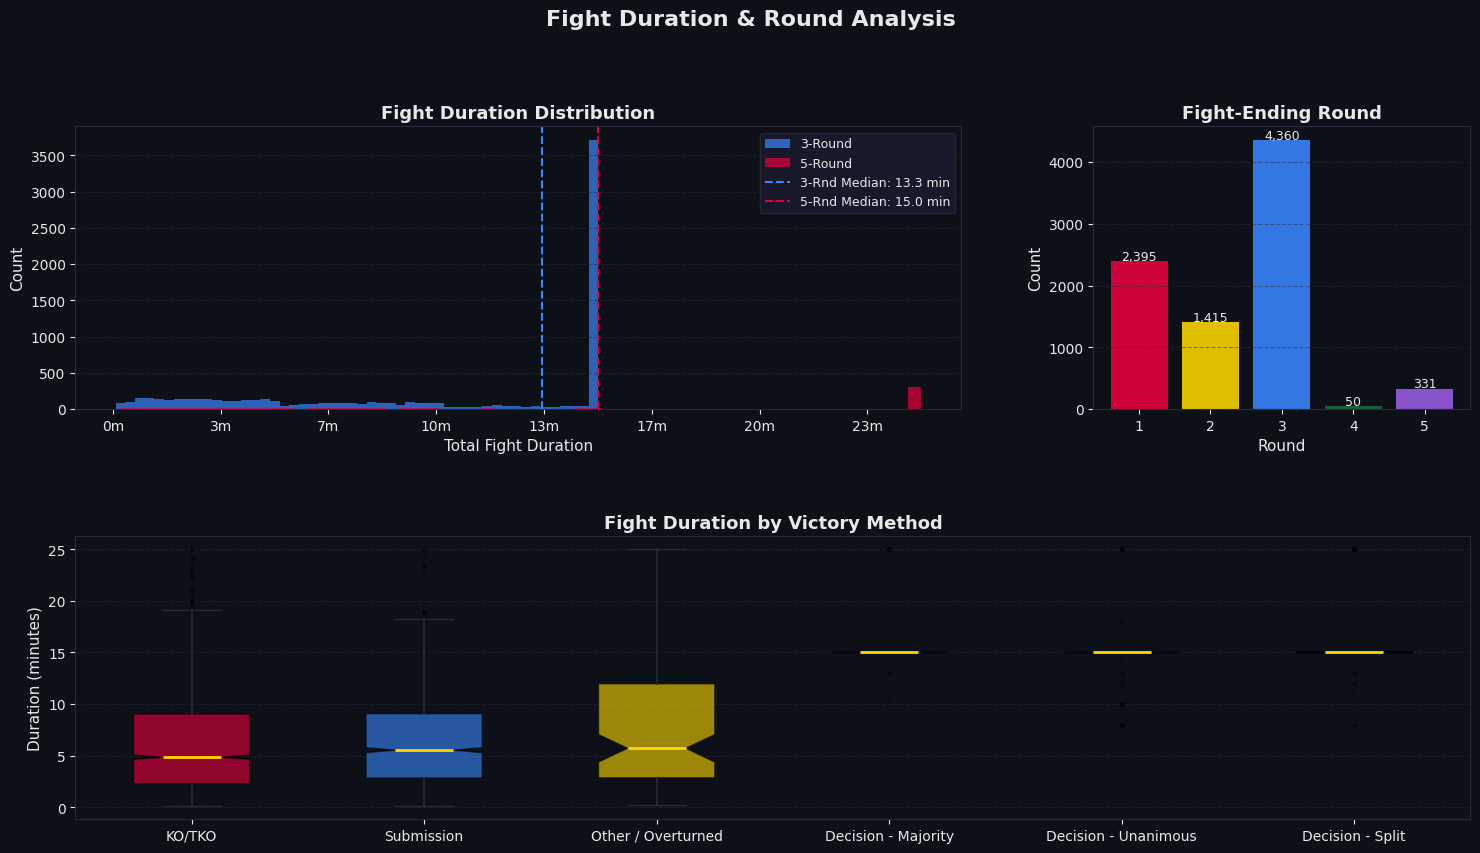


Fight Duration Stats (seconds):
count    8551.0
mean      635.5
std       363.4
min         5.0
25%       280.0
50%       815.0
75%       900.0
max      1500.0
Name: Total_Fight_Time_Sec, dtype: float64


In [ ]:
fig = plt.figure(figsize=(18, 9))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# A – Histogram of total fight time
ax1 = fig.add_subplot(gs[0, :2])
three_rnd = fights[fights['Is_5Rnd'] == 0]['Total_Fight_Time_Sec']
five_rnd  = fights[fights['Is_5Rnd'] == 1]['Total_Fight_Time_Sec']
ax1.hist(three_rnd, bins=60, color=BLUE, alpha=0.7, label='3-Round', edgecolor='none')
ax1.hist(five_rnd,  bins=60, color=RED,  alpha=0.7, label='5-Round', edgecolor='none')
ax1.axvline(three_rnd.median(), color=BLUE, linestyle='--', lw=1.5, label=f'3-Rnd Median: {three_rnd.median()/60:.1f} min')
ax1.axvline(five_rnd.median(),  color=RED,  linestyle='--', lw=1.5, label=f'5-Rnd Median: {five_rnd.median()/60:.1f} min')

# X-axis in minutes
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/60:.0f}m'))
ax1.set_xlabel('Total Fight Duration')
ax1.set_ylabel('Count')
ax1.set_title('Fight Duration Distribution', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y')

# B – Round distribution
ax2 = fig.add_subplot(gs[0, 2])
round_vc = fights['End_Round'].value_counts().sort_index()
ax2.bar(round_vc.index, round_vc.values,
        color=[RED, GOLD, BLUE, GREEN, '#9B5DE5'], edgecolor='none', alpha=0.88)
for x, y in zip(round_vc.index, round_vc.values):
    ax2.text(x, y + 15, f'{y:,}', ha='center', fontsize=9, color=TEXT_COLOR)
ax2.set_xlabel('Round')
ax2.set_ylabel('Count')
ax2.set_title('Fight-Ending Round', fontsize=13, fontweight='bold')
ax2.grid(axis='y')

# C – Box plot: fight time by method
ax3 = fig.add_subplot(gs[1, :])
method_order = fights.groupby('Method_Bucket')['Total_Fight_Time_Sec'].median().sort_values().index.tolist()
data_by_method = [fights[fights['Method_Bucket'] == m]['Total_Fight_Time_Sec'].values / 60
                  for m in method_order]
bp = ax3.boxplot(data_by_method, patch_artist=True, notch=True, vert=True,
                 whiskerprops=dict(color=GRID_COLOR, linewidth=1.2),
                 capprops=dict(color=GRID_COLOR),
                 medianprops=dict(color=GOLD, linewidth=2),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3, color=GRID_COLOR))
box_colors = [RED, BLUE, GOLD, GREEN, '#9B5DE5']
for patch, color in zip(bp['boxes'], box_colors[:len(method_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax3.set_xticks(range(1, len(method_order)+1))
ax3.set_xticklabels(method_order, fontsize=10)
ax3.set_ylabel('Duration (minutes)')
ax3.set_title('Fight Duration by Victory Method', fontsize=13, fontweight='bold')
ax3.grid(axis='y')

plt.suptitle('Fight Duration & Round Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.show()

print('\nFight Duration Stats (seconds):')
print(fights['Total_Fight_Time_Sec'].describe().round(1))

### 4.5 Striking & Grappling Performance

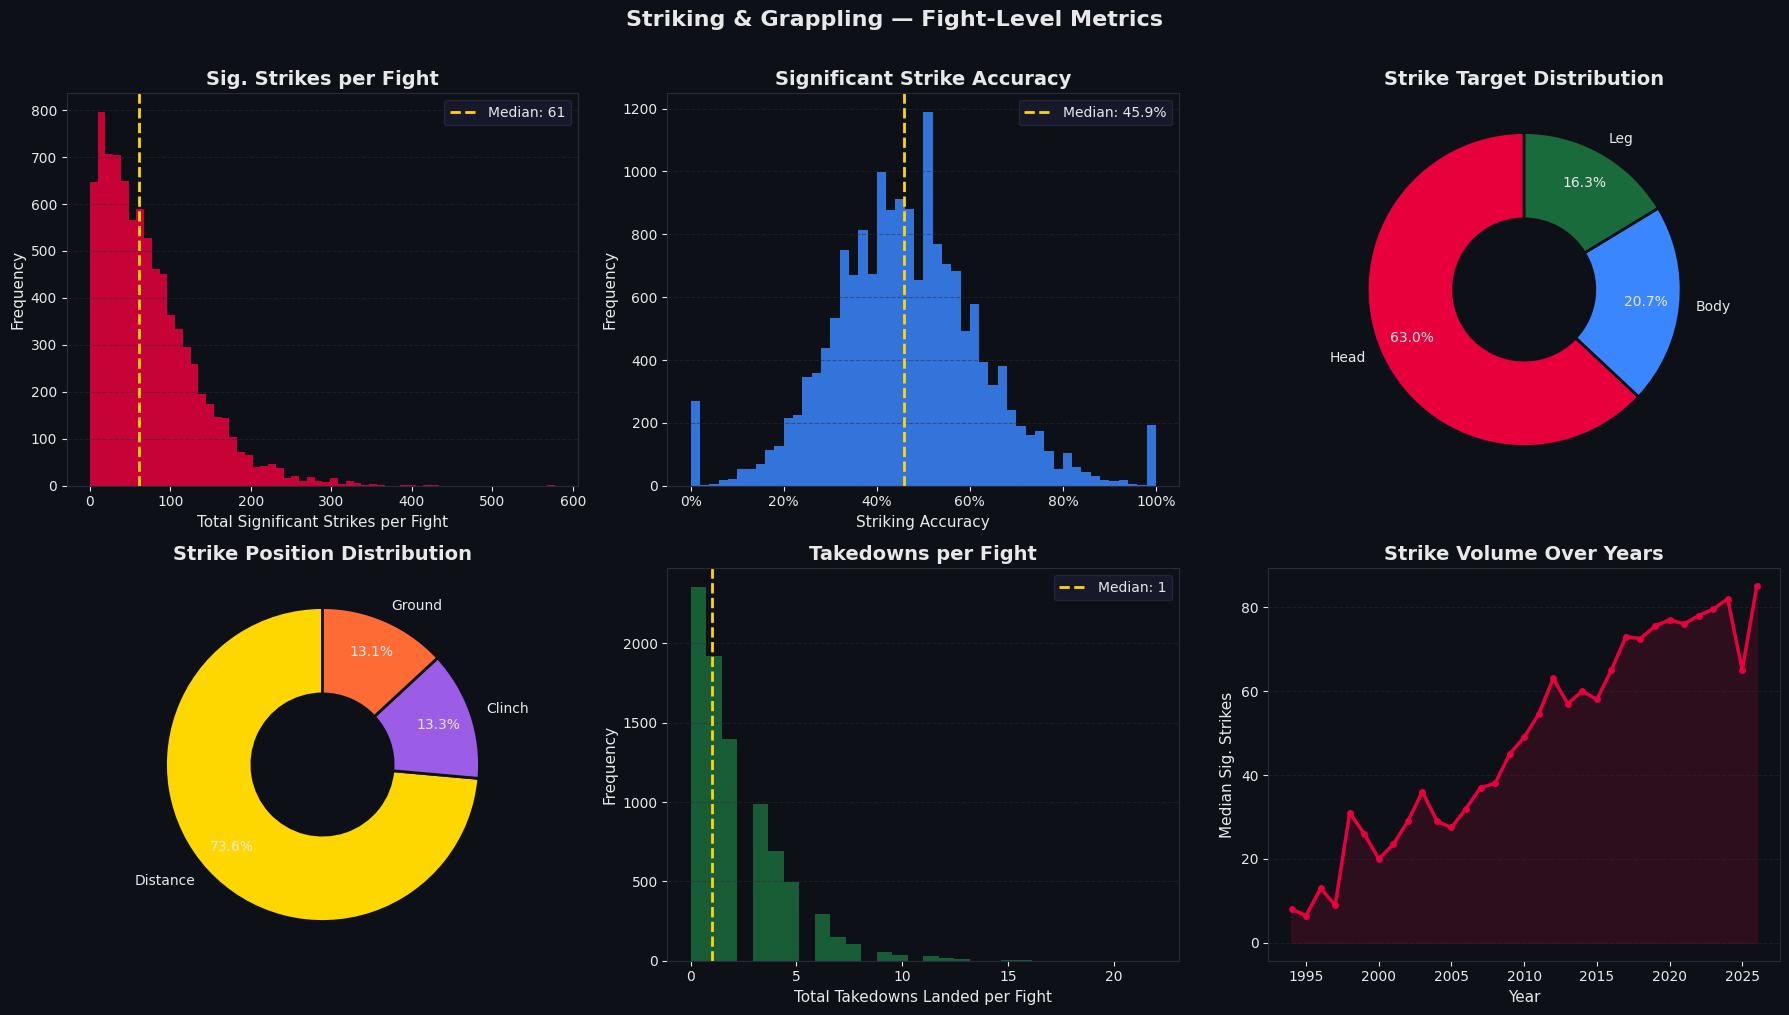


Strike target breakdown : {'Head': 63.0, 'Body': 20.7, 'Leg': 16.3}
Strike position breakdown: {'Distance': 73.6, 'Clinch': 13.3, 'Ground': 13.1}


In [ ]:
# Per-fight combined strike totals
fights['Total_Sig_Strikes']  = fights['F1_Sig_Landed'] + fights['F2_Sig_Landed']
fights['Total_TD_Landed']    = fights['F1_TD_Landed']  + fights['F2_TD_Landed']
fights['Total_Sub_Att']      = fights['F1_Sub_Att']    + fights['F2_Sub_Att']
fights['Total_Ctrl_Sec']     = fights['F1_Ctrl_Sec']   + fights['F2_Ctrl_Sec']
fights['Total_KD']           = fights['F1_KD']         + fights['F2_KD']

# Strike accuracy (avoid division by zero)
fights['F1_Sig_Acc'] = np.where(fights['F1_Sig_Att'] > 0,
                                fights['F1_Sig_Landed'] / fights['F1_Sig_Att'], np.nan)
fights['F2_Sig_Acc'] = np.where(fights['F2_Sig_Att'] > 0,
                                fights['F2_Sig_Landed'] / fights['F2_Sig_Att'], np.nan)

# Strike location breakdown
loc_cols_f1 = ['F1_Head', 'F1_Body', 'F1_Leg']
loc_cols_f2 = ['F2_Head', 'F2_Body', 'F2_Leg']
loc_totals  = pd.Series({
    'Head': fights[loc_cols_f1[0]].sum() + fights[loc_cols_f2[0]].sum(),
    'Body': fights[loc_cols_f1[1]].sum() + fights[loc_cols_f2[1]].sum(),
    'Leg':  fights[loc_cols_f1[2]].sum() + fights[loc_cols_f2[2]].sum(),
})

pos_totals = pd.Series({
    'Distance': fights['F1_Distance'].sum() + fights['F2_Distance'].sum(),
    'Clinch':   fights['F1_Clinch'].sum()   + fights['F2_Clinch'].sum(),
    'Ground':   fights['F1_Ground'].sum()   + fights['F2_Ground'].sum(),
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# A – Distribution of significant strikes per fight
ax = axes[0, 0]
ax.hist(fights['Total_Sig_Strikes'], bins=60, color=RED, alpha=0.85, edgecolor='none')
ax.axvline(fights['Total_Sig_Strikes'].median(), color=GOLD, linestyle='--', lw=2,
           label=f"Median: {fights['Total_Sig_Strikes'].median():.0f}")
ax.set_xlabel('Total Significant Strikes per Fight')
ax.set_ylabel('Frequency')
ax.set_title('Sig. Strikes per Fight', fontweight='bold')
ax.legend()
ax.grid(axis='y')

# B – Strike accuracy distribution
ax = axes[0, 1]
acc_vals = pd.concat([fights['F1_Sig_Acc'].dropna(), fights['F2_Sig_Acc'].dropna()])
ax.hist(acc_vals, bins=50, color=BLUE, alpha=0.85, edgecolor='none')
ax.axvline(acc_vals.median(), color=GOLD, linestyle='--', lw=2,
           label=f"Median: {acc_vals.median()*100:.1f}%")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Striking Accuracy')
ax.set_ylabel('Frequency')
ax.set_title('Significant Strike Accuracy', fontweight='bold')
ax.legend()
ax.grid(axis='y')

# C – Strike target (head/body/leg) donut
ax = axes[0, 2]
ax.pie(loc_totals.values, labels=loc_totals.index,
       colors=[RED, BLUE, GREEN],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'width': 0.55, 'edgecolor': BG_COLOR, 'linewidth': 2},
       pctdistance=0.78)
ax.set_title('Strike Target Distribution', fontweight='bold')

# D – Strike position (distance/clinch/ground) donut
ax = axes[1, 0]
ax.pie(pos_totals.values, labels=pos_totals.index,
       colors=[GOLD, '#9B5DE5', '#FF6B35'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'width': 0.55, 'edgecolor': BG_COLOR, 'linewidth': 2},
       pctdistance=0.78)
ax.set_title('Strike Position Distribution', fontweight='bold')

# E – Takedowns per fight
ax = axes[1, 1]
ax.hist(fights['Total_TD_Landed'], bins=30, color=GREEN, alpha=0.85, edgecolor='none')
ax.axvline(fights['Total_TD_Landed'].median(), color=GOLD, linestyle='--', lw=2,
           label=f"Median: {fights['Total_TD_Landed'].median():.0f}")
ax.set_xlabel('Total Takedowns Landed per Fight')
ax.set_ylabel('Frequency')
ax.set_title('Takedowns per Fight', fontweight='bold')
ax.legend()
ax.grid(axis='y')

# F – Sig. strikes per fight: yearly trend
ax = axes[1, 2]
yearly_strikes = fights.groupby('Year')['Total_Sig_Strikes'].median()
ax.plot(yearly_strikes.index, yearly_strikes.values, color=RED, lw=2.5, marker='o', ms=4)
ax.fill_between(yearly_strikes.index, yearly_strikes.values, alpha=0.15, color=RED)
ax.set_xlabel('Year')
ax.set_ylabel('Median Sig. Strikes')
ax.set_title('Strike Volume Over Years', fontweight='bold')
ax.grid(axis='y')

plt.suptitle('Striking & Grappling — Fight-Level Metrics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nStrike target breakdown : {(loc_totals / loc_totals.sum() * 100).round(1).to_dict()}")
print(f"Strike position breakdown: {(pos_totals / pos_totals.sum() * 100).round(1).to_dict()}")

---
## 5. Fighter-Level EDA
### 5.1 Physical Attributes

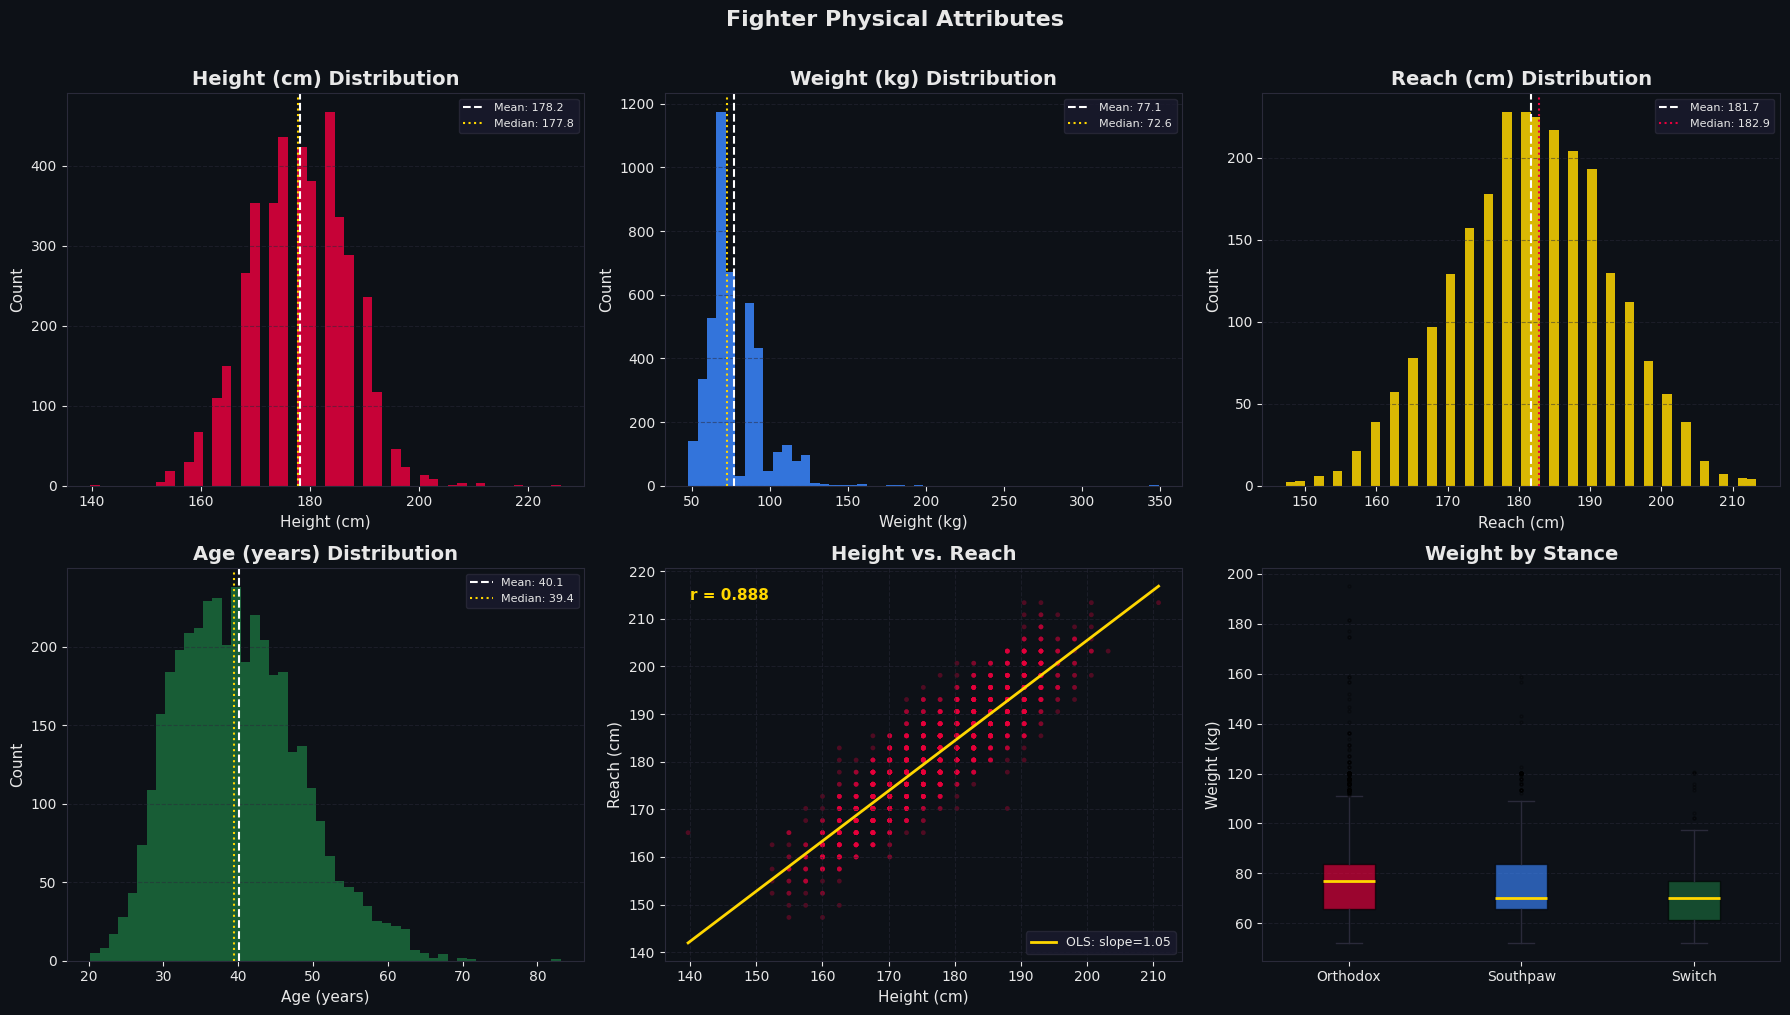

Physical attribute summary:


,Height_cm,Weight_kg,Reach_cm,Age
count,4137.00,4369.00,2515.00,3949.00
mean,178.16,77.14,181.75,40.10
std,8.98,17.95,10.84,8.35
min,139.70,47.63,147.32,20.20
25%,172.72,65.77,175.26,33.80
50%,177.80,72.57,182.88,39.40
75%,185.42,83.91,190.50,45.40
max,226.06,349.27,213.36,83.10


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

phys_cols = [
    ('Height_cm', 'Height (cm)', RED),
    ('Weight_kg', 'Weight (kg)', BLUE),
    ('Reach_cm',  'Reach (cm)',  GOLD),
    ('Age',       'Age (years)', GREEN),
]

for idx, (col, label, color) in enumerate(phys_cols):
    ax = axes[idx // 3][idx % 3]
    data = fighters[col].dropna()
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(),   color='white',   linestyle='--', lw=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color=GOLD if color != GOLD else RED,
               linestyle=':', lw=1.5, label=f'Median: {data.median():.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Distribution', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y')

# Height vs Reach scatter
ax5 = axes[1][1]
valid = fighters[['Height_cm', 'Reach_cm']].dropna()
scatter = ax5.scatter(valid['Height_cm'], valid['Reach_cm'],
                      alpha=0.3, s=12, c=RED, edgecolors='none')
# Trend line
m, b = np.polyfit(valid['Height_cm'], valid['Reach_cm'], 1)
x_line = np.linspace(valid['Height_cm'].min(), valid['Height_cm'].max(), 200)
ax5.plot(x_line, m * x_line + b, color=GOLD, lw=2, label=f'OLS: slope={m:.2f}')
ax5.set_xlabel('Height (cm)')
ax5.set_ylabel('Reach (cm)')
ax5.set_title('Height vs. Reach', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid()
corr = valid.corr().iloc[0, 1]
ax5.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax5.transAxes,
         fontsize=11, color=GOLD, fontweight='bold')

# Weight distribution by stance box
ax6 = axes[1][2]
stance_order = ['Orthodox', 'Southpaw', 'Switch']
data_by_stance = [fighters[fighters['Stance'] == s]['Weight_kg'].dropna().values
                  for s in stance_order]
bp = ax6.boxplot(data_by_stance, patch_artist=True, notch=False,
                 medianprops=dict(color=GOLD, linewidth=2),
                 whiskerprops=dict(color=GRID_COLOR),
                 capprops=dict(color=GRID_COLOR),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3, color=GRID_COLOR))
for patch, color in zip(bp['boxes'], [RED, BLUE, GREEN]):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax6.set_xticks([1, 2, 3])
ax6.set_xticklabels(stance_order)
ax6.set_ylabel('Weight (kg)')
ax6.set_title('Weight by Stance', fontweight='bold')
ax6.grid(axis='y')

plt.suptitle('Fighter Physical Attributes', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Physical attribute summary:')
fighters[['Height_cm', 'Weight_kg', 'Reach_cm', 'Age']].describe().round(2)

### 5.2 Stance Distribution

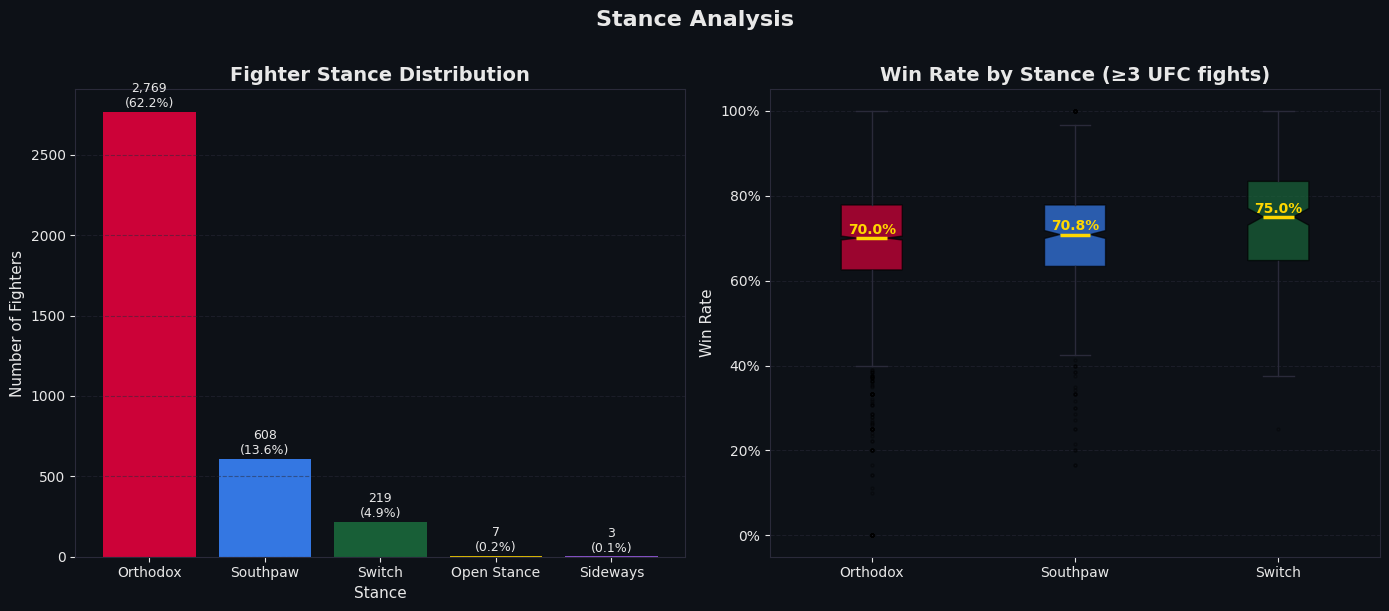

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar – raw counts
ax = axes[0]
stance_vc = fighters['Stance'].value_counts()
colors_s = [RED, BLUE, GREEN, GOLD, '#9B5DE5']
bars = ax.bar(stance_vc.index, stance_vc.values,
              color=colors_s[:len(stance_vc)], edgecolor='none', alpha=0.88)
for bar, v in zip(bars, stance_vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 10,
            f'{v:,}\n({v/len(fighters)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, color=TEXT_COLOR)
ax.set_xlabel('Stance')
ax.set_ylabel('Number of Fighters')
ax.set_title('Fighter Stance Distribution', fontweight='bold')
ax.grid(axis='y')

# Box – Win rate by stance
ax2 = axes[1]
stance_order_wr = ['Orthodox', 'Southpaw', 'Switch']
wr_data = [fighters[(fighters['Stance'] == s) & (fighters['Total_Fights'] >= 3)]['Win_Rate'].dropna().values
           for s in stance_order_wr]
bp = ax2.boxplot(wr_data, patch_artist=True, notch=True,
                 medianprops=dict(color=GOLD, linewidth=2.5),
                 whiskerprops=dict(color=GRID_COLOR),
                 capprops=dict(color=GRID_COLOR),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3, color=GRID_COLOR))
for patch, color in zip(bp['boxes'], [RED, BLUE, GREEN]):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(stance_order_wr)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_ylabel('Win Rate')
ax2.set_title('Win Rate by Stance (≥3 UFC fights)', fontweight='bold')
ax2.grid(axis='y')

# Annotation
for i, (s, data) in enumerate(zip(stance_order_wr, wr_data), 1):
    ax2.text(i, np.median(data) + 0.01, f'{np.median(data)*100:.1f}%',
             ha='center', fontsize=10, color=GOLD, fontweight='bold')

plt.suptitle('Stance Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Career Records

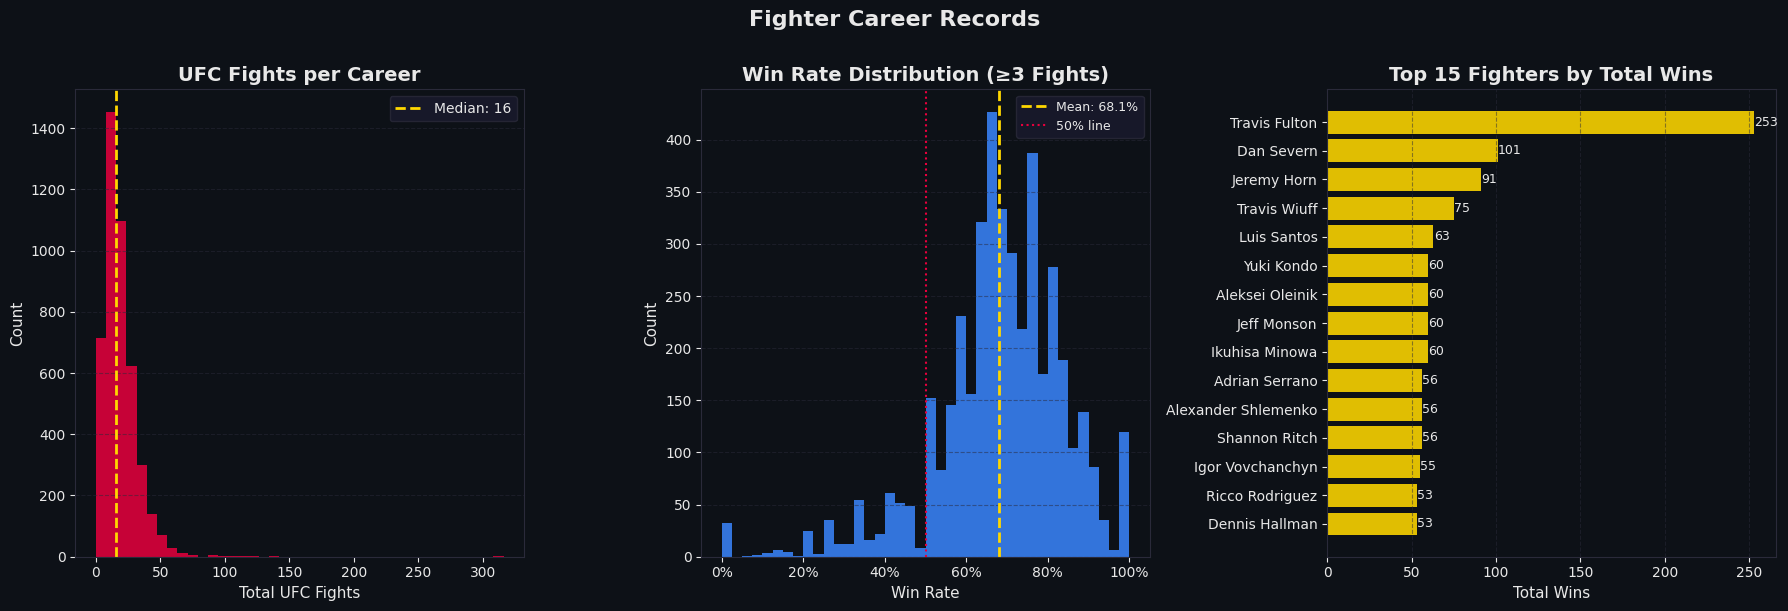

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A – Total fights distribution
ax = axes[0]
ax.hist(fighters['Total_Fights'], bins=40, color=RED, alpha=0.85, edgecolor='none')
ax.axvline(fighters['Total_Fights'].median(), color=GOLD, linestyle='--', lw=2,
           label=f"Median: {fighters['Total_Fights'].median():.0f}")
ax.set_xlabel('Total UFC Fights')
ax.set_ylabel('Count')
ax.set_title('UFC Fights per Career', fontweight='bold')
ax.legend()
ax.grid(axis='y')

# B – Win rate distribution (fighters with ≥3 fights)
ax2 = axes[1]
wr_filtered = fighters[fighters['Total_Fights'] >= 3]['Win_Rate'].dropna()
ax2.hist(wr_filtered, bins=40, color=BLUE, alpha=0.85, edgecolor='none')
ax2.axvline(wr_filtered.mean(),   color=GOLD, linestyle='--', lw=2,
            label=f'Mean: {wr_filtered.mean()*100:.1f}%')
ax2.axvline(0.5, color=RED, linestyle=':', lw=1.5, label='50% line')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_xlabel('Win Rate')
ax2.set_ylabel('Count')
ax2.set_title('Win Rate Distribution (≥3 Fights)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y')

# C – Top 15 winningest fighters
ax3 = axes[2]
top15 = fighters.nlargest(15, 'Wins')[['Fighter_Name', 'Wins']].sort_values('Wins')
bars = ax3.barh(top15['Fighter_Name'], top15['Wins'], color=GOLD, alpha=0.88, edgecolor='none')
for bar, v in zip(bars, top15['Wins']):
    ax3.text(v + 0.1, bar.get_y() + bar.get_height()/2,
             str(v), va='center', fontsize=9, color=TEXT_COLOR)
ax3.set_xlabel('Total Wins')
ax3.set_title('Top 15 Fighters by Total Wins', fontweight='bold')
ax3.grid(axis='x')

plt.suptitle('Fighter Career Records', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Performance Ratings (Averages)

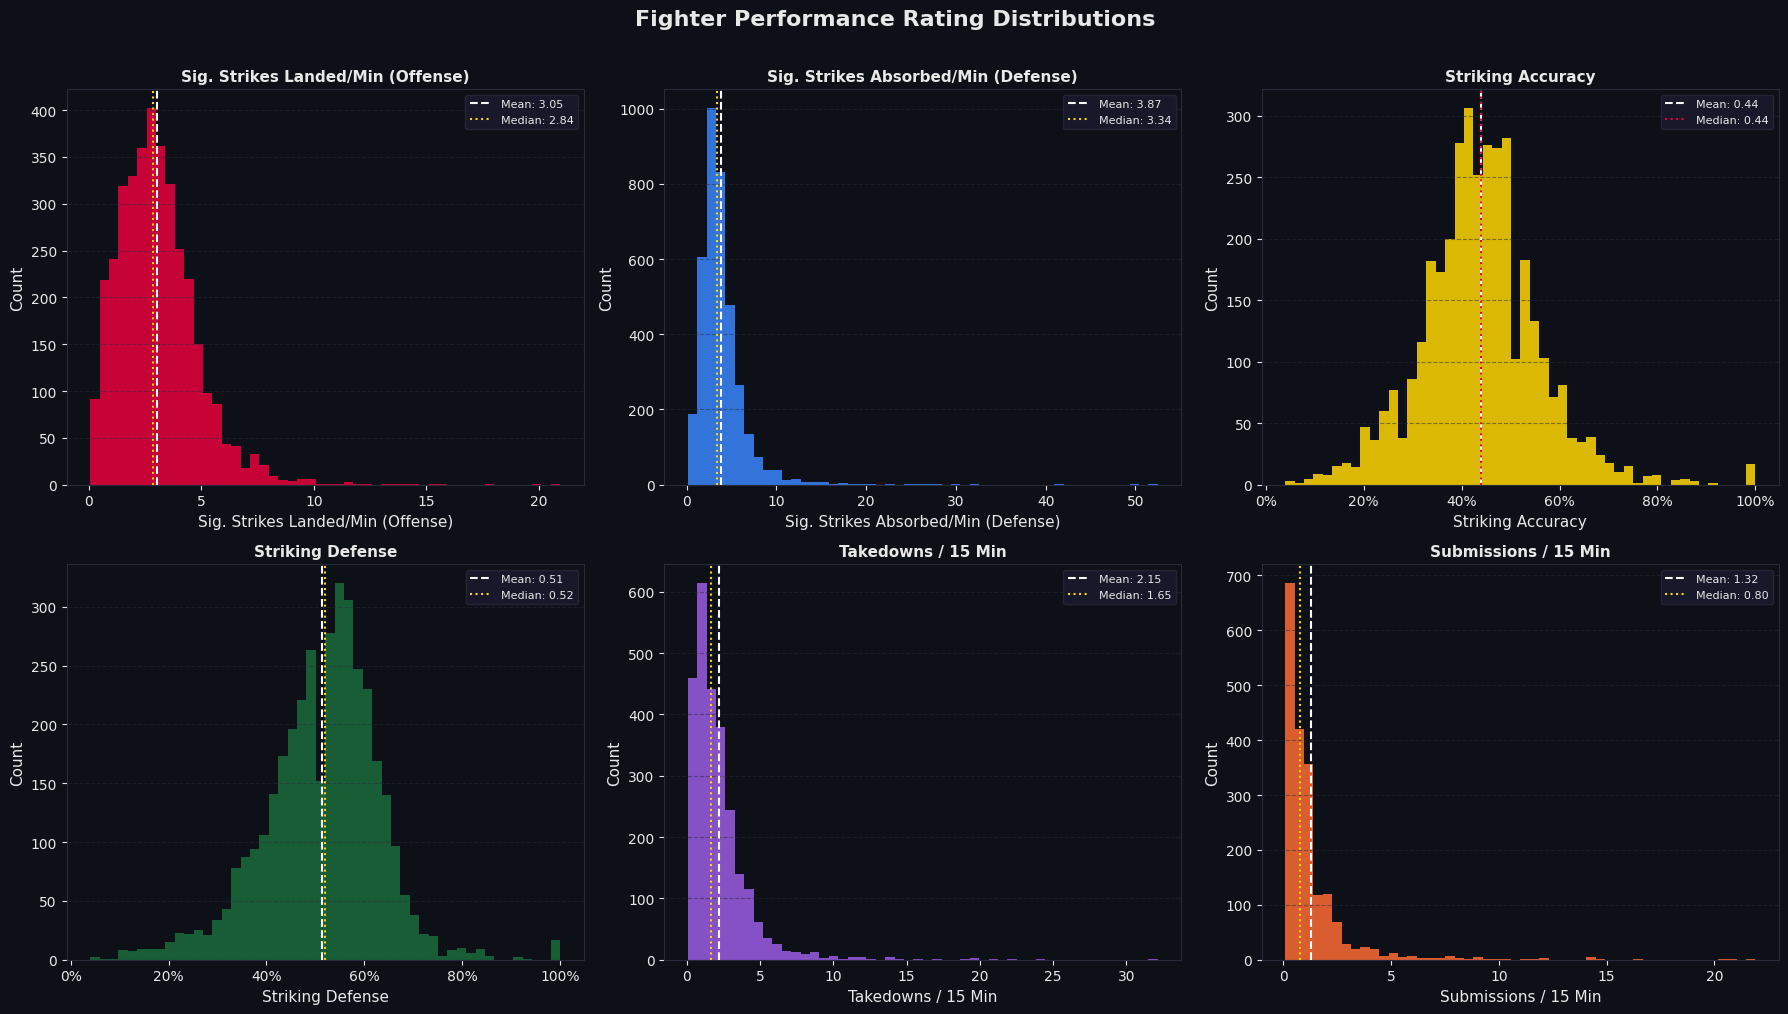


Performance stat summaries:


,SLpM,SApM,Str_Acc,Str_Def,TD_Avg,Sub_Avg
count,4455.000,4455.000,4455.000,4455.000,4455.000,4455.000
mean,2.502,3.239,0.360,0.429,1.256,0.573
std,2.015,2.943,0.201,0.219,1.940,1.442
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.900,1.660,0.280,0.360,0.000,0.000
50%,2.410,2.990,0.410,0.500,0.600,0.000
75%,3.690,4.305,0.490,0.570,1.940,0.700
max,20.950,52.500,1.000,1.000,32.140,21.900


In [ ]:
perf_cols = {
    'SLpM':    ('Sig. Strikes Landed/Min (Offense)', RED),
    'SApM':    ('Sig. Strikes Absorbed/Min (Defense)', BLUE),
    'Str_Acc': ('Striking Accuracy', GOLD),
    'Str_Def': ('Striking Defense',  GREEN),
    'TD_Avg':  ('Takedowns / 15 Min', '#9B5DE5'),
    'Sub_Avg': ('Submissions / 15 Min', '#FF6B35'),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (col, (label, color)) in zip(axes.flatten(), perf_cols.items()):
    data = fighters[col].dropna()
    # Remove absolute zeros (unfought / data missing coded as 0)
    data = data[data > 0]
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(),   color='white', linestyle='--', lw=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color=GOLD if color != GOLD else RED,
               linestyle=':', lw=1.5, label=f'Median: {data.median():.2f}')
    if col in ('Str_Acc', 'Str_Def'):
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y')

plt.suptitle('Fighter Performance Rating Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nPerformance stat summaries:')
fighters[list(perf_cols.keys())].describe().round(3)

---
## 6. Era-Based Trend Analysis

Examining how fighting styles and dominant methods have evolved across five major UFC eras.

    Era  Fights  Finish_Rate  KO_TKO_Rate  Sub_Rate  Decision_Rate  Avg_Fight_Min  Avg_Sig_Strikes  Avg_TD
1994–99     203        0.823        0.438     0.384          0.163          5.420           18.448   1.236
2000–05     296        0.686        0.456     0.230          0.294          8.699           34.064   2.193
2006–11    1298        0.577        0.337     0.240          0.417          9.782           52.660   2.433
2012–15    1703        0.506        0.318     0.188          0.473         10.558           66.668   2.196
2016–19    1940        0.486        0.311     0.175          0.504         11.126           81.029   1.984
2020–26    3035        0.490        0.315     0.175          0.497         11.108           89.576   2.089


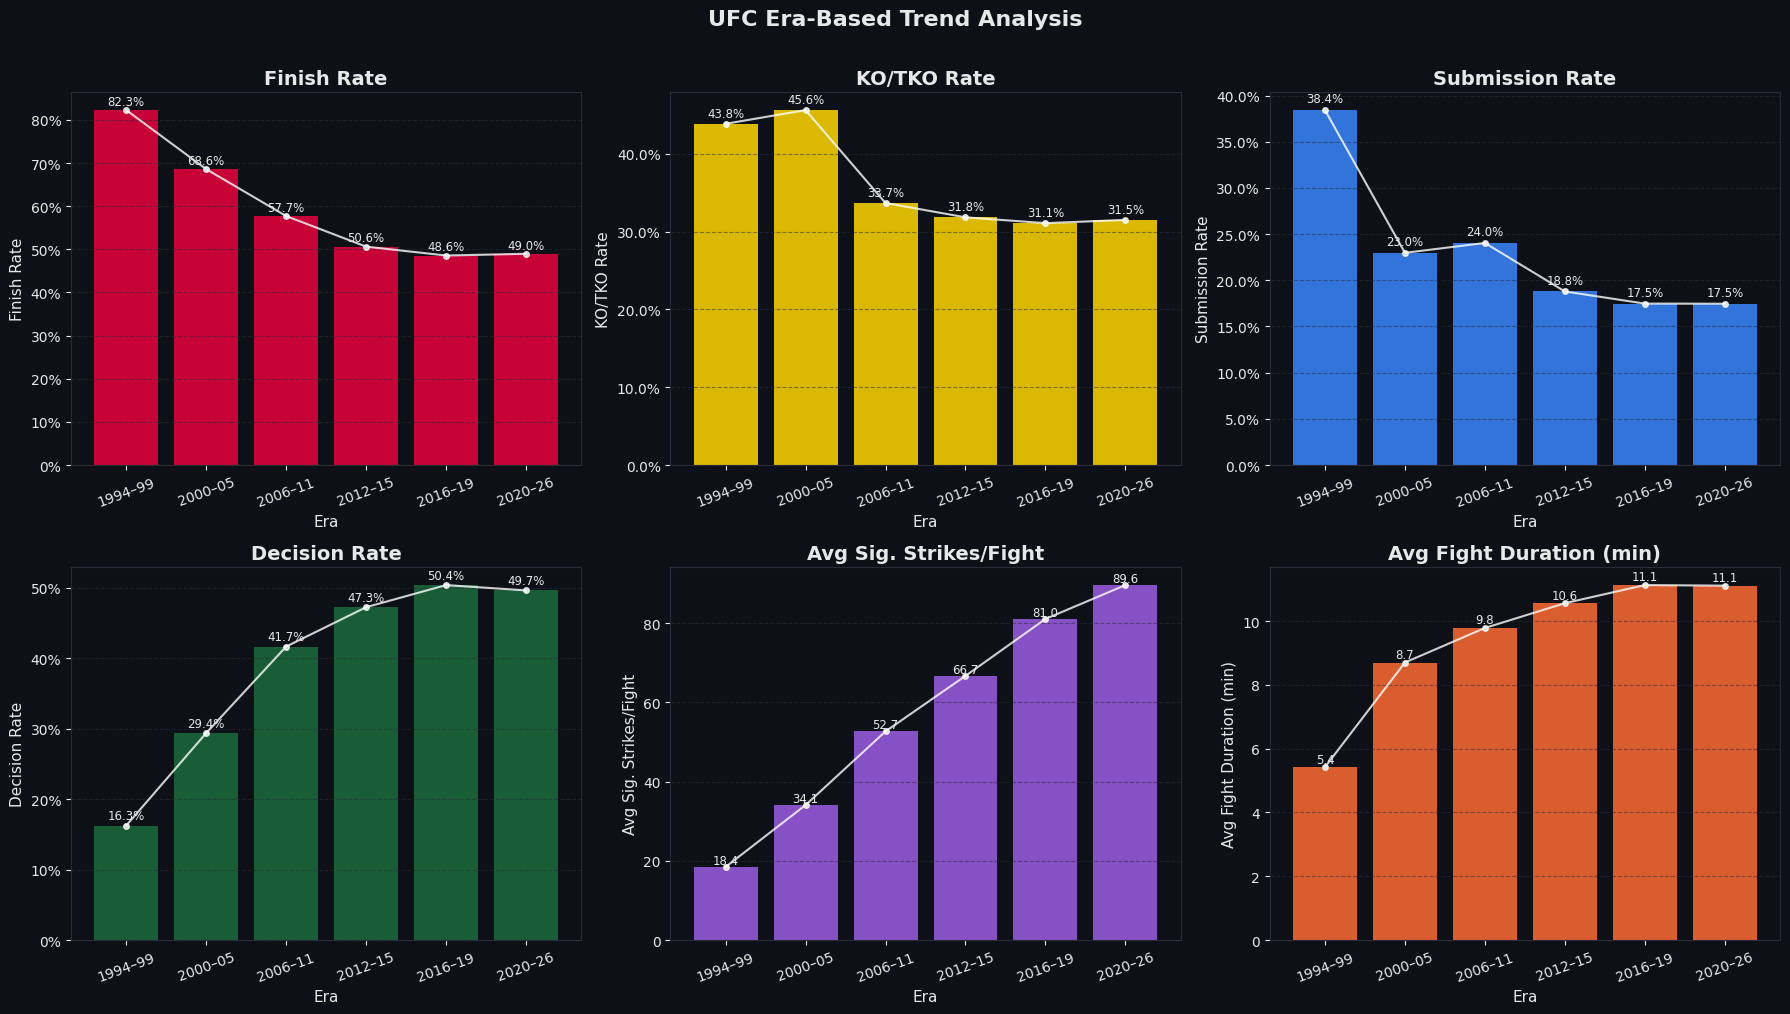

In [ ]:
era_metrics = fights.groupby('Era', observed=True).agg(
    Fights           = ('Fight_URL', 'count'),
    Finish_Rate      = ('Is_Finish', 'mean'),
    KO_TKO_Rate      = ('Method_Bucket', lambda x: (x == 'KO/TKO').mean()),
    Sub_Rate         = ('Method_Bucket', lambda x: (x == 'Submission').mean()),
    Decision_Rate    = ('Is_Decision', 'mean'),
    Avg_Fight_Min    = ('Total_Fight_Time_Sec', lambda x: (x / 60).mean()),
    Avg_Sig_Strikes  = ('Total_Sig_Strikes', 'mean'),
    Avg_TD           = ('Total_TD_Landed', 'mean'),
).reset_index()

print(era_metrics.to_string(index=False, float_format='%.3f'))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = [
    ('Finish_Rate',     'Finish Rate',            RED,    True),
    ('KO_TKO_Rate',     'KO/TKO Rate',            GOLD,   True),
    ('Sub_Rate',        'Submission Rate',         BLUE,   True),
    ('Decision_Rate',   'Decision Rate',           GREEN,  True),
    ('Avg_Sig_Strikes', 'Avg Sig. Strikes/Fight',  '#9B5DE5', False),
    ('Avg_Fight_Min',   'Avg Fight Duration (min)', '#FF6B35', False),
]

for ax, (col, label, color, is_pct) in zip(axes.flatten(), metrics_to_plot):
    bars = ax.bar(era_metrics['Era'], era_metrics[col] * (100 if is_pct else 1),
                  color=color, alpha=0.85, edgecolor='none')
    ax.plot(era_metrics['Era'], era_metrics[col] * (100 if is_pct else 1),
            color='white', lw=1.5, marker='o', ms=4, alpha=0.8)
    for bar, v in zip(bars, era_metrics[col]):
        val = v * 100 if is_pct else v
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if is_pct else 0.05),
                f'{val:.1f}{"%" if is_pct else ""}',
                ha='center', va='bottom', fontsize=8.5, color=TEXT_COLOR)
    if is_pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlabel('Era')
    ax.set_ylabel(label)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y')

plt.suptitle('UFC Era-Based Trend Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Correlation Analysis

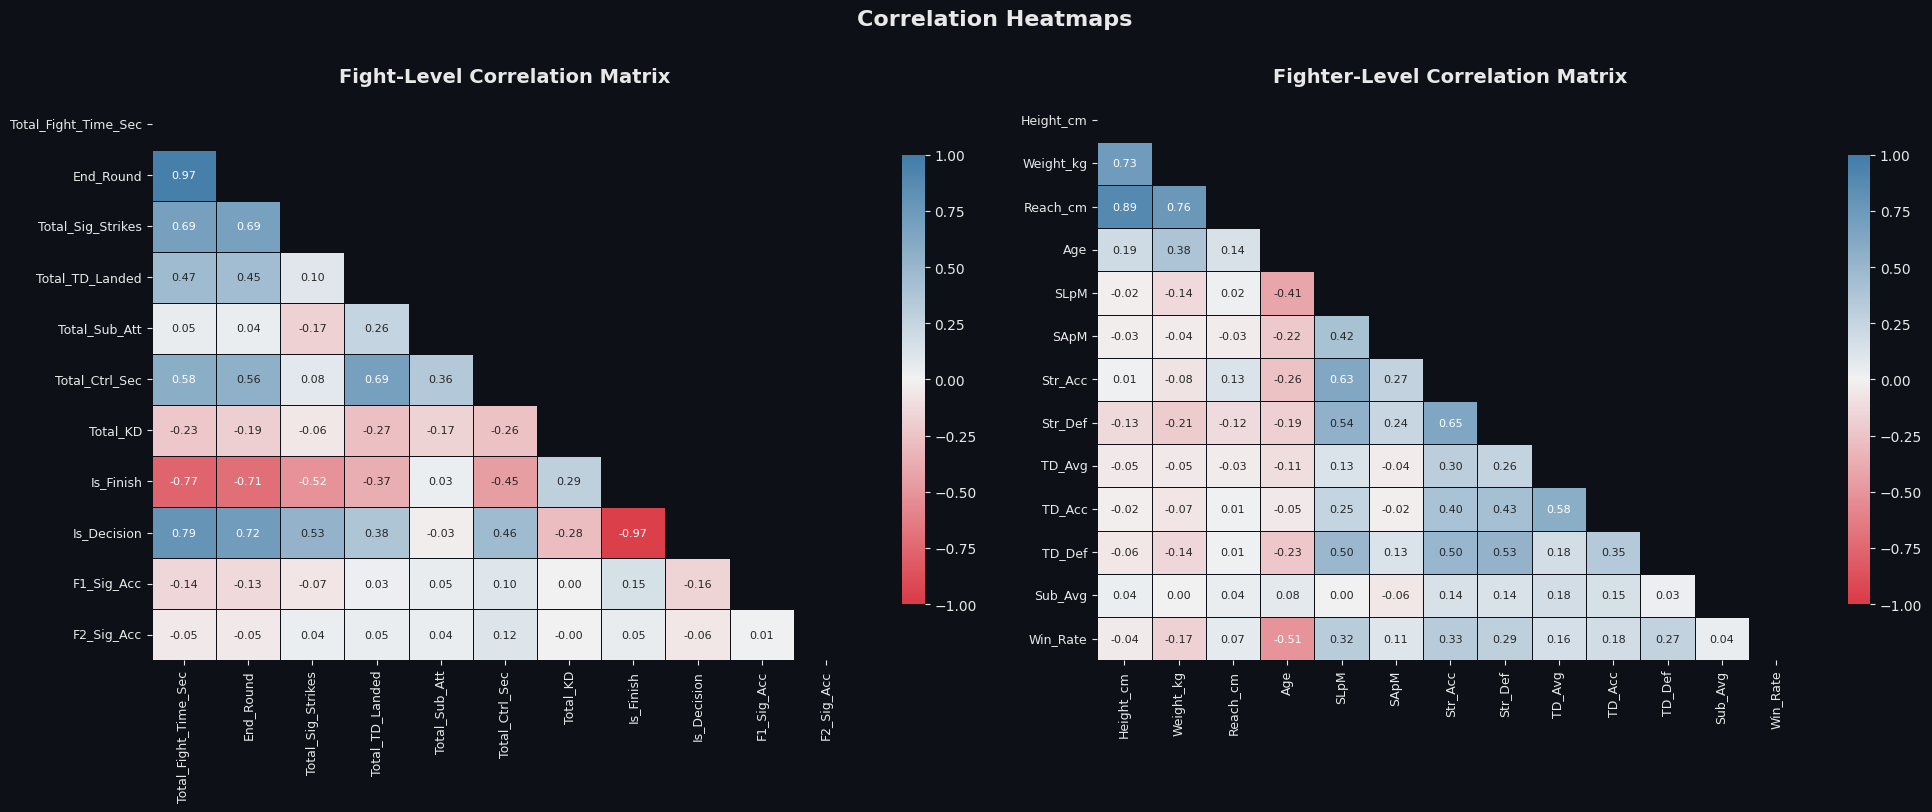


Top features correlated with Win_Rate:
Age          0.510190
Str_Acc      0.332487
SLpM         0.323474
Str_Def      0.286390
TD_Def       0.269706
TD_Acc       0.182296
Weight_kg    0.173427
TD_Avg       0.159445
SApM         0.108036
Reach_cm     0.068419
Name: Win_Rate, dtype: float64


In [ ]:
# ── Fight-level correlation heatmap ─────────────────────────────────────────
fight_corr_cols = [
    'Total_Fight_Time_Sec', 'End_Round', 'Total_Sig_Strikes',
    'Total_TD_Landed', 'Total_Sub_Att', 'Total_Ctrl_Sec', 'Total_KD',
    'Is_Finish', 'Is_Decision',
    'F1_Sig_Acc', 'F2_Sig_Acc',
]

corr_fights = fights[fight_corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Fight heatmap
mask = np.triu(np.ones_like(corr_fights, dtype=bool))
sns.heatmap(corr_fights, ax=axes[0], mask=mask,
            cmap=sns.diverging_palette(10, 240, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor=BG_COLOR,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Fight-Level Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
axes[0].tick_params(axis='both', labelsize=9)

# Fighter-level
fighter_corr_cols = [
    'Height_cm', 'Weight_kg', 'Reach_cm', 'Age',
    'SLpM', 'SApM', 'Str_Acc', 'Str_Def',
    'TD_Avg', 'TD_Acc', 'TD_Def', 'Sub_Avg', 'Win_Rate',
]
corr_fighters = fighters[fighter_corr_cols].corr()
mask2 = np.triu(np.ones_like(corr_fighters, dtype=bool))
sns.heatmap(corr_fighters, ax=axes[1], mask=mask2,
            cmap=sns.diverging_palette(10, 240, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor=BG_COLOR,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Fighter-Level Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
axes[1].tick_params(axis='both', labelsize=9)

plt.suptitle('Correlation Heatmaps', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Top 10 strongest correlations with Win_Rate
wr_corr = corr_fighters['Win_Rate'].drop('Win_Rate').abs().sort_values(ascending=False)
print('\nTop features correlated with Win_Rate:')
print(wr_corr.head(10))

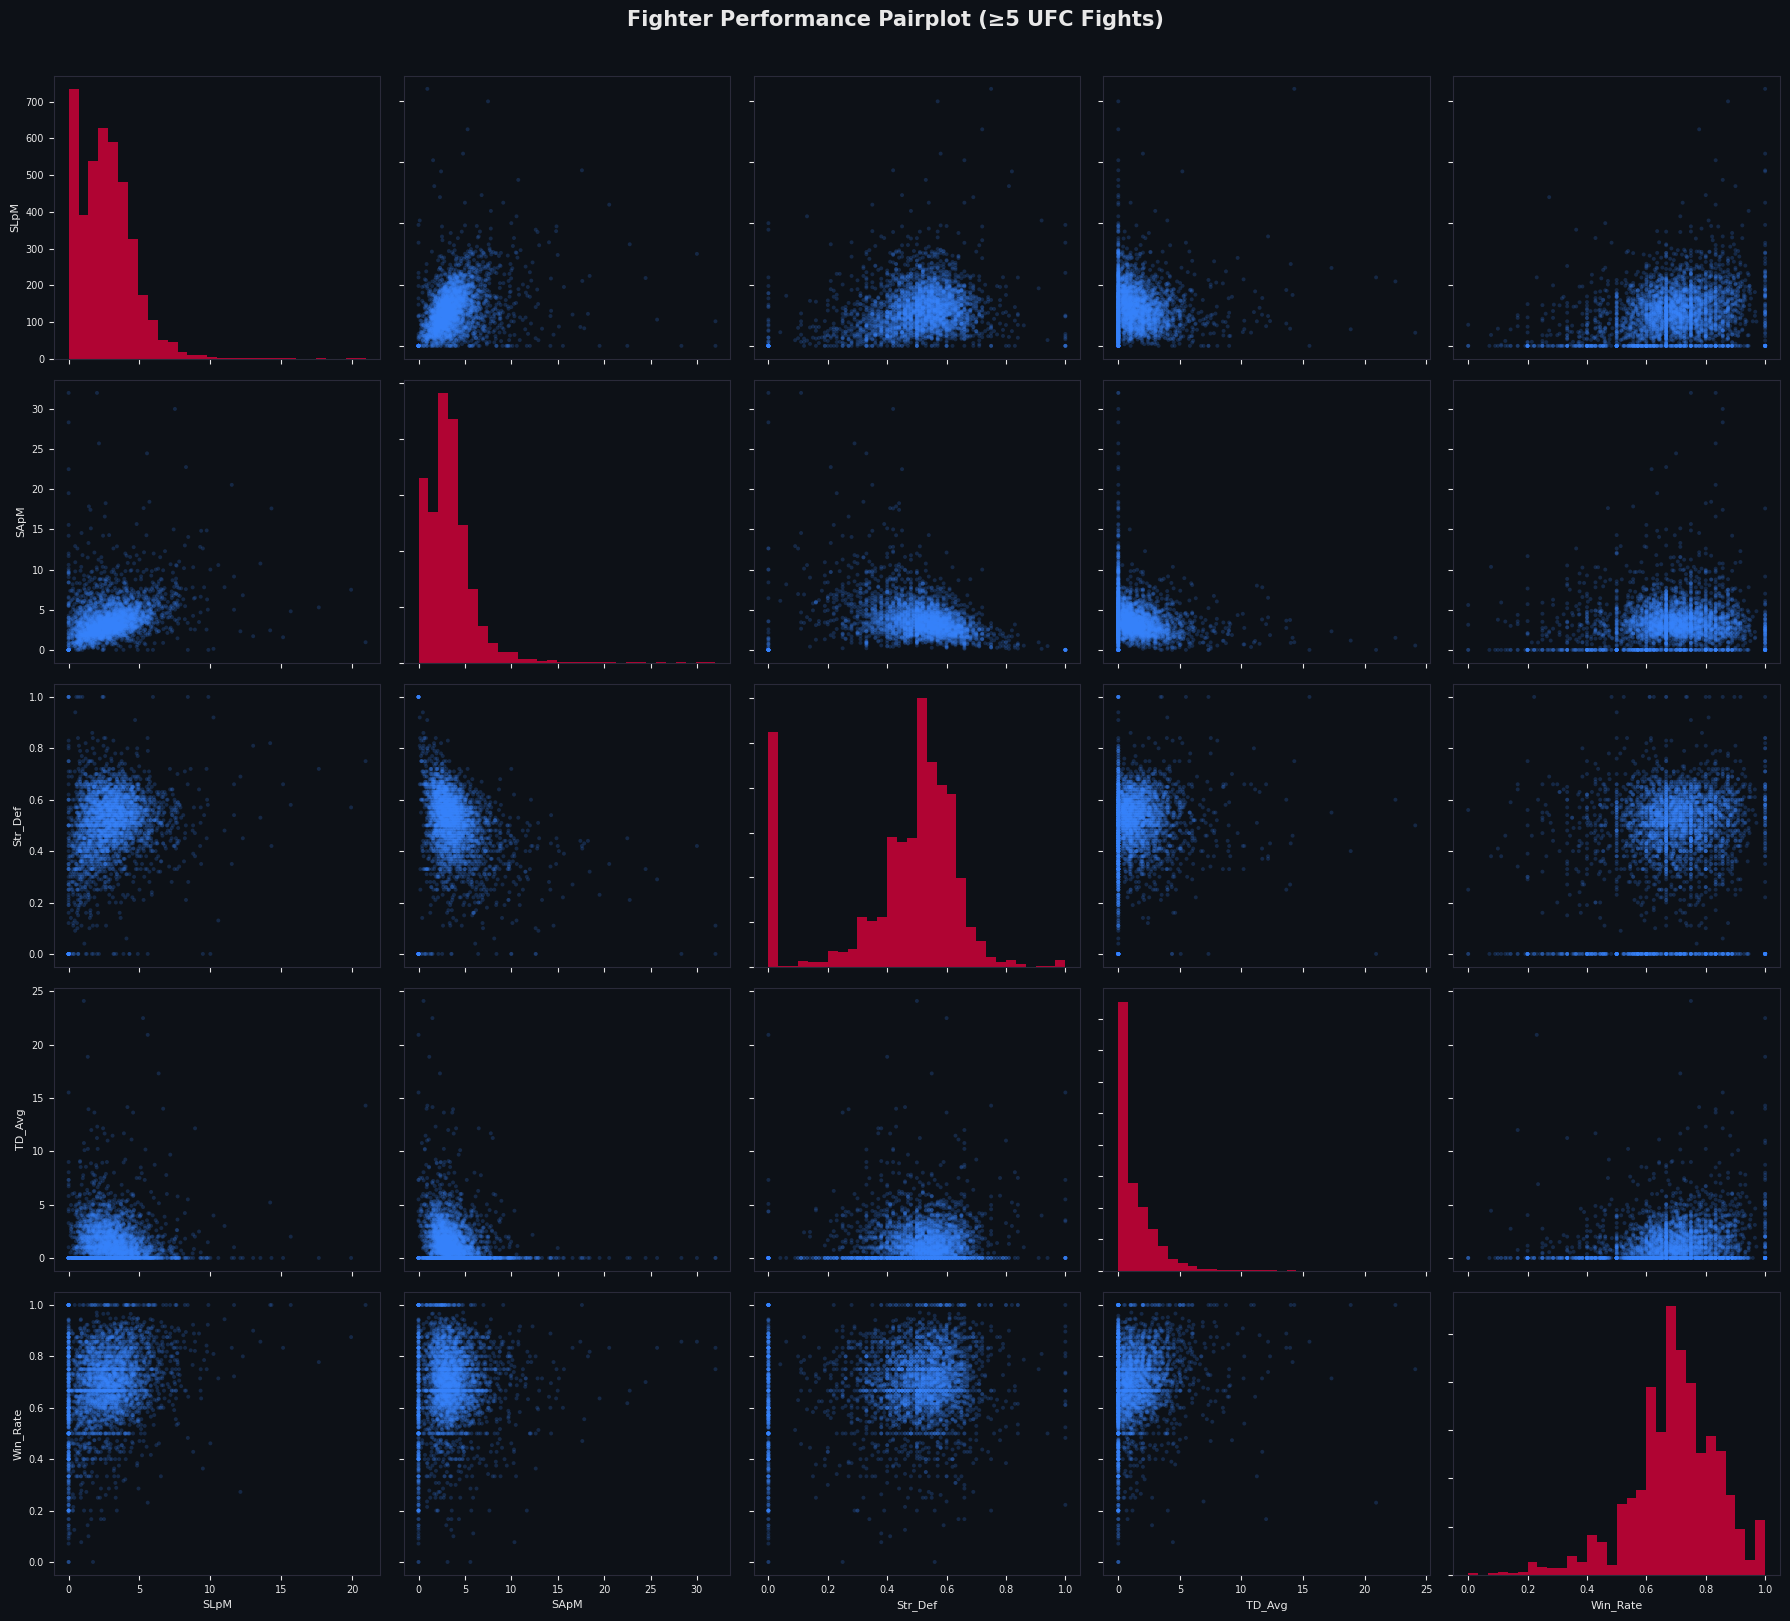

In [ ]:
# Pairplot — key offensive vs defensive metrics for fighters with ≥5 UFC fights
fighters_active = fighters[
    (fighters['Total_Fights'] >= 5) &
    fighters[['SLpM', 'SApM', 'Str_Def', 'TD_Avg', 'Win_Rate']].notna().all(axis=1)
].copy()

pair_cols = ['SLpM', 'SApM', 'Str_Def', 'TD_Avg', 'Win_Rate']

fig, axes = plt.subplots(len(pair_cols), len(pair_cols), figsize=(18, 16))

for i, col_y in enumerate(pair_cols):
    for j, col_x in enumerate(pair_cols):
        ax = axes[i][j]
        if i == j:
            data = fighters_active[col_y].dropna()
            ax.hist(data, bins=30, color=RED, alpha=0.75, edgecolor='none')
        else:
            ax.scatter(fighters_active[col_x], fighters_active[col_y],
                       alpha=0.2, s=8, color=BLUE, edgecolors='none')
        if i == len(pair_cols) - 1:
            ax.set_xlabel(col_x, fontsize=8)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(col_y, fontsize=8)
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=7)

plt.suptitle('Fighter Performance Pairplot (≥5 UFC Fights)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Key Insights Summary

In [ ]:
# Compute the key numbers for the summary card
total_fights      = len(fights)
total_fighters    = len(fighters)
date_range        = f"{fights['Event_Date'].min().year}–{fights['Event_Date'].max().year}"
finish_rate       = fights['Is_Finish'].mean() * 100
ko_rate           = (fights['Method_Bucket'] == 'KO/TKO').mean() * 100
sub_rate          = (fights['Method_Bucket'] == 'Submission').mean() * 100
dec_rate          = fights['Is_Decision'].mean() * 100
avg_fight_min     = fights['Total_Fight_Time_Sec'].mean() / 60
median_sig_str    = fights['Total_Sig_Strikes'].median()
avg_height        = fighters['Height_cm'].mean()
avg_reach         = fighters['Reach_cm'].mean()
orthodox_pct      = (fighters['Stance'] == 'Orthodox').mean() * 100
reach_height_corr = fighters[['Height_cm', 'Reach_cm']].dropna().corr().iloc[0,1]

# Early vs modern era finish rates
early_fr  = fights[fights['Year'] < 2000]['Is_Finish'].mean() * 100
modern_fr = fights[fights['Year'] >= 2015]['Is_Finish'].mean() * 100

insights = f"""
╔══════════════════════════════════════════════════════════════════════╗
║              UFC EDA — KEY FINDINGS SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset Scope                                                       ║
║  • {total_fights:,} fights | {total_fighters:,} fighters | {date_range}                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  How Fights End                                                      ║
║  • Overall finish rate  : {finish_rate:.1f}%                              ║
║    - KO/TKO             : {ko_rate:.1f}%                              ║
║    - Submission         : {sub_rate:.1f}%                              ║
║  • Decision rate        : {dec_rate:.1f}%                             ║
║  • Early era (<2000) finish rate  : {early_fr:.1f}%                      ║
║  • Modern era (2015+) finish rate : {modern_fr:.1f}%  (sport maturation)║
╠══════════════════════════════════════════════════════════════════════╣
║  Fight Dynamics                                                      ║
║  • Average fight duration      : {avg_fight_min:.1f} min                    ║
║  • Median sig. strikes/fight   : {median_sig_str:.0f}                           ║
║  • ~66% of strikes target HEAD                                       ║
║  • ~82% of strikes thrown at DISTANCE                                ║
║  • R3 ends most fights (3-round contests go full distance often)     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Fighter Profiles                                                    ║
║  • Avg. height : {avg_height:.1f} cm  |  Avg. reach : {avg_reach:.1f} cm              ║
║  • Height–Reach Pearson r : {reach_height_corr:.3f} (very strong)           ║
║  • {orthodox_pct:.1f}% of fighters are Orthodox stance                      ║
║  • Reach advantage is the key physical modelling feature             ║
╠══════════════════════════════════════════════════════════════════════╣
║  Modelling Implications                                              ║
║  • Finish rate declined over eras → era as a feature matters        ║
║  • Strike accuracy & defense better predictors than raw volume       ║
║  • Reach differential, Str_Def, and SLpM are top features           ║
║  • High % of zeros in Sub_Avg, TD_Avg → consider log(1+x) transform ║
║  • Fighters dataset has 43% missing Reach → impute by weight class  ║
╚══════════════════════════════════════════════════════════════════════╝
"""

print(insights)


╔══════════════════════════════════════════════════════════════════════╗
║              UFC EDA — KEY FINDINGS SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset Scope                                                       ║
║  • 8,551 fights | 4,455 fighters | 1994–2026                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  How Fights End                                                      ║
║  • Overall finish rate  : 51.9%                              ║
║    - KO/TKO             : 32.6%                              ║
║    - Submission         : 19.4%                              ║
║  • Decision rate        : 46.7%                             ║
║  • Early era (<2000) finish rate  : 82.3%                      ║
║  • Modern era (2015+) finish rate : 48.9%  (sport maturation)║
╠══════════════════════════════════════════════════════════════════════╣
║  Fight Dynamics            